In [68]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from typing import cast

REPORTS_DIR = Path("reports")
assert REPORTS_DIR.exists(), f"Path does not exist: {REPORTS_DIR.resolve()}"

METHODS = ["LIME", "MAPLE", "SHAP", "BreakDown"]

LOWER_IS_BETTER = {
    "AverageDrop", "AverageStability", "AvgSensitivity", "Complexity",
    "Deletion", "LocalLipschitzEstimate", "MaxSensitivity",
    "NonSensitivity", "RandomLogit", "RelativeInputStability",
    "RelativeOutputStability",
}

HIGHER_IS_BETTER = {
    "AverageGain", "AverageIncrease", "Consistency", "Faithfulness",
    "FaithfulnessEstimate", "Insertion", "MonotonicityCorrelation",
    "MuFidelity", "SensitivityN", "Sparseness", "Sufficiency",
}

BOOLEAN_METRICS = {
    "Completeness",
    "Monotonicity",
    "MonotonicityMetric",
}

METRIC_CHARACTERISTICS = {
    # Complexity
    "Complexity": "Complexity",
    "Sparseness": "Complexity",

    # Faithfulness
    "Consistency": "Faithfulness",
    "Faithfulness": "Faithfulness",
    "FaithfulnessEstimate": "Faithfulness",
    "Monotonicity": "Faithfulness",
    "MonotonicityCorrelation": "Faithfulness",
    "MonotonicityMetric": "Faithfulness",
    "SensitivityN": "Faithfulness",
    "Sufficiency": "Faithfulness",

    # Fidelity
    "AverageDrop": "Fidelity",
    "AverageGain": "Fidelity",
    "AverageIncrease": "Fidelity",
    "Completeness": "Fidelity",
    "Deletion": "Fidelity",
    "Insertion": "Fidelity",
    "MuFidelity": "Fidelity",
    "NonSensitivity": "Fidelity",

    # Robustness
    "AverageStability": "Robustness",
    "LocalLipschitzEstimate": "Robustness",
    "MaxSensitivity": "Robustness",
    "MeGe": "Robustness",
    "RelativeInputStability": "Robustness",
    "RelativeOutputStability": "Robustness",

    # Sensitivity
    "AvgSensitivity": "Sensitivity",
    "ModelRandomization": "Sensitivity",
    "RandomLogit": "Sensitivity"
}

# File load

## File discovery

In [69]:
files = sorted(REPORTS_DIR.rglob("*"))

inventory = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(REPORTS_DIR)),
            "extension": path.suffix,
            "size_kb": round(path.stat().st_size / 1024, 2),
            "modified_at": pd.to_datetime(path.stat().st_atime, unit="s")
        }
        for path in files
        if path.is_file()
    ]
)

display(inventory.sort_values(["extension", "path"]))
print(f"Files found: {len(inventory)}")

,path,extension,size_kb,modified_at
0,AverageDrop\AverageDrop_xai_metrics_report_202...,.csv,123.99,2026-10-05 12:41:47.222599268
1,AverageGain\AverageGain_xai_metrics_report_202...,.csv,117.19,2026-10-05 12:41:47.240316629
2,AverageIncrease\AverageIncrease_xai_metrics_re...,.csv,91.72,2026-10-05 12:41:47.253362417
3,AverageStability\AverageStability_xai_metrics_...,.csv,232.23,2026-10-05 12:41:47.264166116
4,AvgSensitivity\AvgSensitivity_xai_metrics_repo...,.csv,195.62,2026-10-05 12:41:47.274537086
5,Completeness\Completeness_xai_metrics_report_2...,.csv,93.85,2026-10-05 12:41:47.283502817
6,Complexity\Complexity_xai_metrics_report_20260...,.csv,131.22,2026-10-05 12:41:47.299189091
7,Consistency\Consistency_xai_metrics_report_202...,.csv,146.80,2026-10-05 12:41:47.314347744
8,Deletion\Deletion_xai_metrics_report_20260918_...,.csv,235.84,2026-10-05 12:41:47.326280355
10,FaithfulnessEstimate\FaithfulnessEstimate_xai_...,.csv,213.93,2026-10-05 12:41:47.355231762


Files found: 27


## Load the aggregated JSON report

In [70]:
json_files = list(REPORTS_DIR.glob("*.json"))
assert json_files, "No aggregated JSON file was found."

summary_json_path = json_files[0]

with open(summary_json_path, encoding="utf-8") as file:
    summary_json = json.load(file)

summary_wide = pd.json_normalize(summary_json['report'], max_level=0)

summary_long = summary_wide.melt(
    id_vars=['dataset_name', 'model_name', 'metric', 'metric_params'],
    value_vars=[method for method in METHODS if method in summary_wide.columns],
    var_name='method',
    value_name='summary_value'
)

summary_long['summary_value'] = pd.to_numeric(summary_long['summary_value'], errors='coerce')

print(f"Aggregated file: {summary_json_path.name}")
print(f"Aggregated rows: {len(summary_wide)}")
display(summary_wide.head())

Aggregated file: xai_metrics_report_20260624_071542.json
Aggregated rows: 450


,dataset_name,model_name,metric,metric_params,LIME,MAPLE,SHAP,BreakDown
0,AHU21,AutoEncoder,AverageDrop,"{'batch_size': 64, 'activation': None}",0.106299,0.143865,0.165058,0.194760
1,AHU21,AutoEncoder,AverageGain,"{'batch_size': 64, 'activation': None}",0.184601,0.096348,0.188170,0.179413
2,AHU21,AutoEncoder,AverageIncrease,"{'batch_size': 64, 'activation': None}",0.642857,0.414286,0.485714,0.485714
3,AHU21,AutoEncoder,AverageStability,"{'radius': 0.05, 'nb_samples': 100, 'distance'...",0.441245,0.567850,0.047340,0.079540
4,AHU21,AutoEncoder,AvgSensitivity,"{'nr_samples': 100, 'abs': False, 'normalise':...",1.130820,0.810518,1.631231,0.865631


## Load all detailed CSV reports

In [71]:
detailed_csv_paths = [
    path
    for path in REPORTS_DIR.rglob("*.csv")
    if path.parent != REPORTS_DIR
]

detailed_frames = []

for path in detailed_csv_paths:
    metric = path.parent.name
    frame = pd.read_csv(path)

    id_columns = ['dataset_name', 'model_name', 'observation', 'metric_params']
    available_methods = [col for col in METHODS if col in frame.columns]

    long_frame = frame.melt(
        id_vars=[col for col in id_columns if col in frame.columns],
        value_vars=available_methods,
        var_name='method',
        value_name='value'
    )

    long_frame['metric'] = metric
    long_frame['source_file'] = path.name
    long_frame['source_timestamp'] = path.stem.split("_")[-2] + "_" + path.stem.split("_")[-1]
    
    detailed_frames.append(long_frame)

detailed_long = pd.concat(detailed_frames, ignore_index=True)
detailed_long['numeric_value'] = pd.to_numeric(detailed_long['value'], errors='coerce')
detailed_long['is_boolean_value'] = detailed_long['value'].astype(str).isin(['True', 'False'])

print(f"Detailed CSV files: {len(detailed_csv_paths)}")
print(f"Rows in long format: {len(detailed_long):,}")
display(detailed_long.head())

Detailed CSV files: 25
Rows in long format: 109,200


,dataset_name,model_name,observation,metric_params,method,value,metric,source_file,source_timestamp,numeric_value,is_boolean_value
0,AHU21,AutoEncoder,10163,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
1,AHU21,AutoEncoder,10164,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
2,AHU21,AutoEncoder,10165,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
3,AHU21,AutoEncoder,10172,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
4,AHU21,AutoEncoder,10173,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False


# Initial result description

## Experimental coverage

,dataset_name,model_name,observations,metrics
0,AHU21,AutoEncoder,70,25
1,AHU21,ECOD,70,25
2,AHU21,HBOS,70,25
3,AHU21,IForest,70,25
4,AHU21,MCD,70,25
5,AHU21,VAE,70,25
6,ARAMIS20,AutoEncoder,70,25
7,ARAMIS20,ECOD,70,25
8,ARAMIS20,HBOS,70,25
9,ARAMIS20,IForest,70,25


,dataset_name,models,min_observations_per_model,max_observations_per_model
0,AHU21,6,70,70
1,ARAMIS20,6,70,70
2,MetroPT3,6,42,42


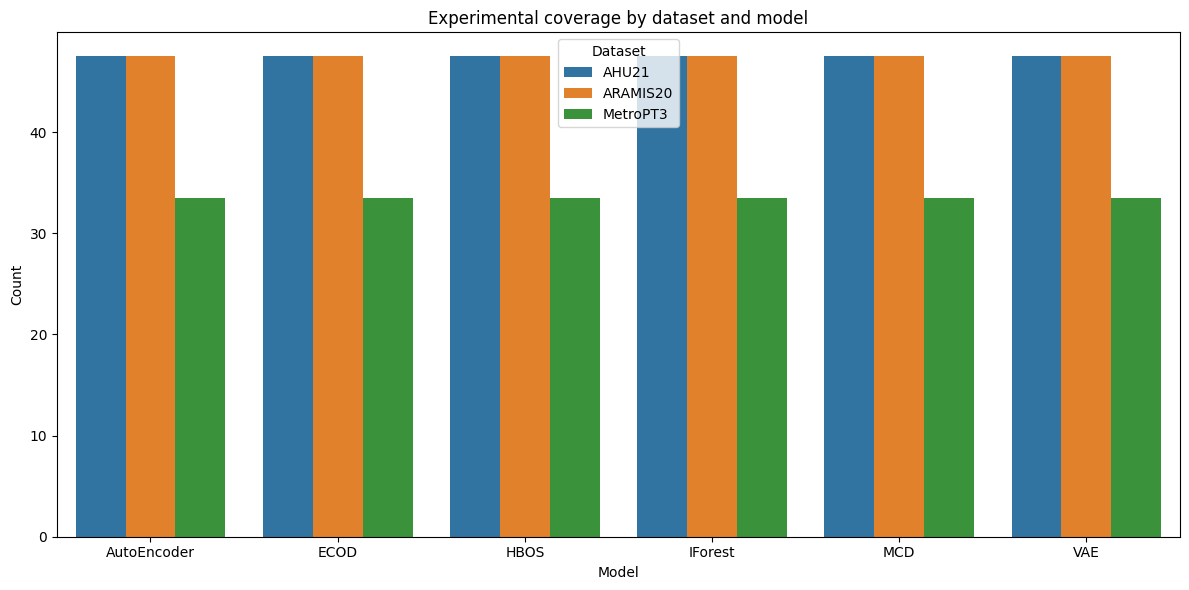

In [72]:
coverage = (
    detailed_long[['dataset_name', 'model_name', 'observation', 'metric']]
    .drop_duplicates()
    .groupby(['dataset_name', 'model_name'], as_index=False)
    .agg(observations=('observation', 'nunique'), metrics=('metric', 'nunique'))
    .sort_values(['dataset_name', 'model_name'])
)

display(coverage)

coverage_dataset = (
    coverage.groupby('dataset_name', as_index=False)
    .agg(
        models=('model_name', 'nunique'),
        min_observations_per_model=('observations', 'min'),
        max_observations_per_model=('observations', 'max')
    )
)

display(coverage_dataset)

coverage_plot = coverage.melt(
    id_vars=['dataset_name', 'model_name'],
    value_vars=['observations', 'metrics'],
    var_name='measure',
    value_name='value'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=coverage_plot,
    x='model_name',
    y='value',
    hue='dataset_name',
    errorbar=None
)
plt.title("Experimental coverage by dataset and model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Missing values and unavailable metrics

,metric,method,total,valid,missing,missing_percentage
88,SensitivityN,BreakDown,1092,0,1092,100.000000
89,SensitivityN,LIME,1092,0,1092,100.000000
90,SensitivityN,MAPLE,1092,0,1092,100.000000
91,SensitivityN,SHAP,1092,0,1092,100.000000
87,RelativeOutputStability,SHAP,1092,556,536,49.084249
80,RelativeInputStability,BreakDown,1092,577,515,47.161172
81,RelativeInputStability,LIME,1092,577,515,47.161172
83,RelativeInputStability,SHAP,1092,577,515,47.161172
85,RelativeOutputStability,LIME,1092,577,515,47.161172
86,RelativeOutputStability,MAPLE,1092,577,515,47.161172


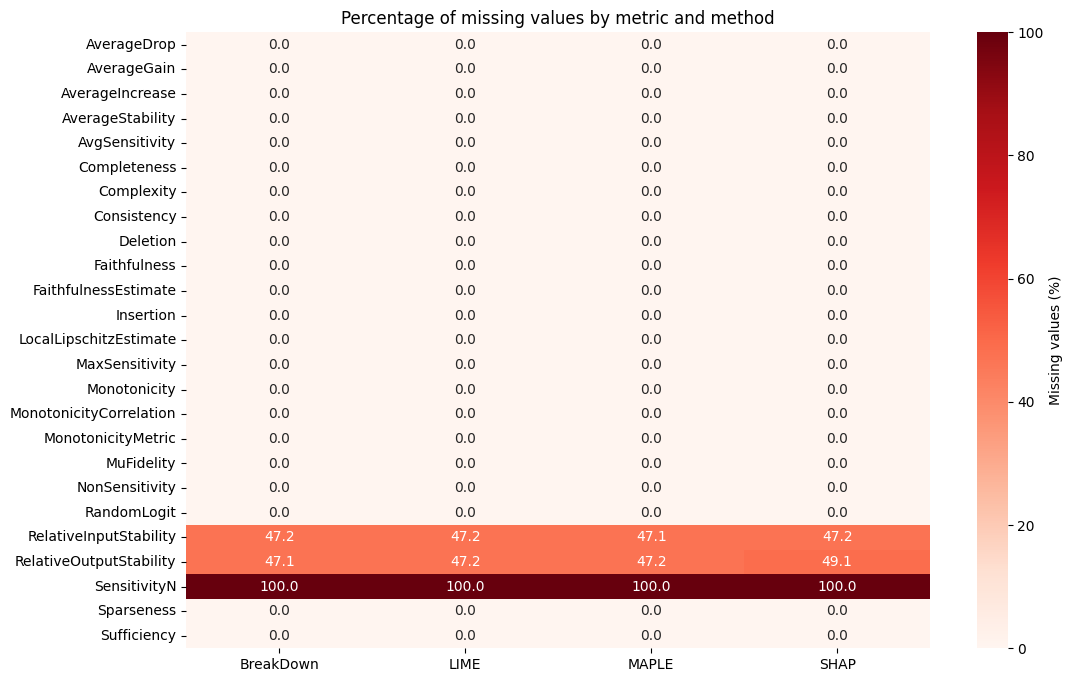

In [73]:
missingness = (
    detailed_long.groupby(['metric', 'method'], as_index=False)
    .agg(
        total=('value', 'size'),
        valid=('numeric_value', 'count'),
        missing=('numeric_value', lambda x: x.isna().sum())
    )
)

missingness['missing_percentage'] = (100 * missingness['missing'] / missingness['total'])

missingness = missingness.sort_values(['missing_percentage', 'metric', 'method'], ascending=[False, True, True])

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(missingness)

plt.figure(figsize=(12, 8))
heatmap_missing = missingness.pivot(index='metric', columns='method', values='missing_percentage')

sns.heatmap(
    heatmap_missing,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Missing values (%)"},
)
plt.title("Percentage of missing values by metric and method")
plt.xlabel("")
plt.ylabel("")
plt.show()

## Duplicate records

In [74]:
duplicate_keys = (
    detailed_long.groupby(['metric', 'dataset_name', 'model_name', 'observation', 'method'], dropna=False)
    .size()
    .reset_index(name='count')
    .query("count > 1")
    .sort_values('count', ascending=False)
)

print(f"Duplicate keys: {len(duplicate_keys)}")
display(duplicate_keys)

if not duplicate_keys.empty:
    duplicated_rows = detailed_long.merge(
        duplicate_keys[['metric', 'dataset_name', 'model_name', 'observation', 'method']],
        on=['metric', 'dataset_name', 'model_name', 'observation', 'method'],
        how='inner'
    ).sort_values(['metric', 'dataset_name', 'model_name', 'observation', 'method'])

    display(duplicated_rows)

Duplicate keys: 0


,metric,dataset_name,model_name,observation,method,count


## Validate JSON summary values against detailed CSV mean

In [75]:
csv_means = (
    detailed_long[~detailed_long['metric'].isin(BOOLEAN_METRICS)]
    .dropna(subset=['numeric_value'])
    .groupby(['dataset_name', 'model_name', 'metric', 'method'], as_index=False)
    .agg(
        csv_mean=('numeric_value', 'mean'),
        n_valid=('numeric_value', 'size')
    )
)

summary_comparison = summary_long.merge(
    csv_means,
    on=['dataset_name', 'model_name', 'metric', 'method'],
    how='outer'
)

summary_comparison['difference'] = summary_comparison['summary_value'] - summary_comparison['csv_mean']
summary_comparison['abs_difference'] = summary_comparison['difference'].abs()
summary_comparison['matches'] = np.isclose(
    summary_comparison['summary_value'],
    summary_comparison['csv_mean'],
    atol=1e-9,
    equal_nan=True
)

comparable_rows = summary_comparison[
    summary_comparison['summary_value'].notna() & summary_comparison['csv_mean'].notna()
].copy()

comparable_rows['matches'] = np.isclose(
    comparable_rows['summary_value'],
    comparable_rows['csv_mean'],
    atol=1e-9
)

discrepancies = (comparable_rows.loc[~comparable_rows['matches']].sort_values('abs_difference', ascending=False))


print(f"Comparable rows: {len(comparable_rows)}")
print(f"Exact matches: {comparable_rows['matches'].sum()} / {len(comparable_rows)}")

display(discrepancies)

Comparable rows: 1510
Exact matches: 1510 / 1510


,dataset_name,model_name,metric,metric_params,method,summary_value,csv_mean,n_valid,difference,abs_difference,matches


# Statistics

## Global statistical summary bymetric

In [76]:
numeric_results = detailed_long[
    (~detailed_long['metric'].isin(BOOLEAN_METRICS)) & detailed_long['numeric_value'].notna()
].copy()

global_stats = pd.DataFrame(
    numeric_results.groupby(['metric'], as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median'),
        std=('numeric_value', 'std'),
        p05=('numeric_value', lambda x: x.quantile(0.05)),
        p95=('numeric_value', lambda x: x.quantile(0.95)),
        min=('numeric_value', 'min'),
        max=('numeric_value', 'max')
    )
)

global_stats['direction'] = np.select(
    [global_stats['metric'].isin(LOWER_IS_BETTER), global_stats['metric'].isin(HIGHER_IS_BETTER)],
    ["lower is better", "higher is better"],
    default="unknown"
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(global_stats.sort_values(['metric']))

,metric,n,mean,median,std,p05,p95,min,max,direction
0,AverageDrop,4368,3.078479e-01,0.055770,3.748016e-01,0.000000,1.000000e+00,0.000000e+00,1.000000e+00,lower is better
1,AverageGain,4368,2.465434e-01,0.000000,3.573612e-01,0.000000,9.999999e-01,0.000000e+00,1.000000e+00,higher is better
2,AverageIncrease,4368,4.381868e-01,0.000000,4.962212e-01,0.000000,1.000000e+00,0.000000e+00,1.000000e+00,higher is better
3,AverageStability,4368,2.135992e-01,0.087061,3.191504e-01,0.004310,7.699422e-01,0.000000e+00,3.454678e+00,lower is better
4,AvgSensitivity,4368,1.149354e+02,1.018927,2.513987e+03,0.243656,3.472496e+00,3.275383e-02,9.097839e+04,lower is better
5,Complexity,4368,1.697602e+00,1.676691,5.632528e-01,0.702159,2.535794e+00,-1.000089e-12,2.763931e+00,lower is better
6,Consistency,4368,7.462527e-01,0.902439,2.582472e-01,0.243902,1.000000e+00,0.000000e+00,1.000000e+00,higher is better
7,Deletion,4368,5.175687e-01,0.492152,3.220332e-01,0.062218,9.989650e-01,2.985803e-05,1.000000e+00,lower is better
8,Faithfulness,4368,-9.970462e-02,-0.102792,5.149889e-01,-0.940298,7.938354e-01,-9.999955e-01,9.994563e-01,higher is better
9,FaithfulnessEstimate,4368,-2.860406e-02,-0.038232,5.151135e-01,-0.864625,8.245288e-01,-9.999986e-01,9.999970e-01,higher is better


## Global winner per metric

In [77]:
def get_winners(stats, score_column):
    winner_rows = []

    for metric, group in stats.groupby('metric'):
        if metric in LOWER_IS_BETTER:
            winner = group.loc[group[score_column].idxmin()].copy()
        elif metric in HIGHER_IS_BETTER:
            winner = group.loc[group[score_column].idxmax()].copy()
        else:
            continue

        winner['metric'] = metric
        winner_rows.append(winner)

    return pd.DataFrame(winner_rows).reset_index(drop=True)

,metric,winner_by_mean,winner_mean,direction
0,AverageDrop,LIME,0.299574,lower is better
1,AverageGain,SHAP,0.258318,higher is better
2,AverageIncrease,LIME,0.465201,higher is better
3,AverageStability,SHAP,0.064165,lower is better
4,AvgSensitivity,LIME,1.057664,lower is better
5,Complexity,MAPLE,1.614178,lower is better
6,Consistency,MAPLE,0.752274,higher is better
7,Deletion,SHAP,0.511972,lower is better
8,Faithfulness,MAPLE,0.049824,higher is better
9,FaithfulnessEstimate,MAPLE,0.038638,higher is better


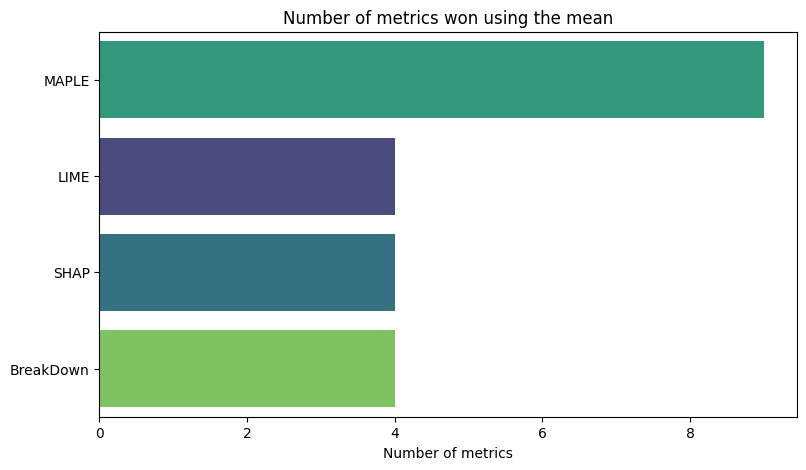

In [78]:
method_stats = pd.DataFrame(
    numeric_results.groupby(['metric', 'method'], as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median'),
        std=('numeric_value', 'std'),
        p05=('numeric_value', lambda x: x.quantile(0.05)),
        p95=('numeric_value', lambda x: x.quantile(0.95)),
        min=('numeric_value', 'min'),
        max=('numeric_value', 'max')
    )
)

method_stats['direction'] = np.select(
    [method_stats['metric'].isin(LOWER_IS_BETTER), method_stats['metric'].isin(HIGHER_IS_BETTER)],
    ["lower is better", "higher is better"],
    default="unknown"
)

mean_winners = get_winners(method_stats, "mean")

winners = (
    mean_winners[['metric', 'method', 'mean', 'direction']]
    .rename(
        columns={
            "method": "winner_by_mean",
            "mean": "winner_mean"
        }
    )
)

display(winners.sort_values('metric'))

plt.figure(figsize=(9, 5))
sns.countplot(
    data=winners,
    y='winner_by_mean',
    hue='winner_by_mean',
    order=winners['winner_by_mean'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title("Number of metrics won using the mean")
plt.xlabel("Number of metrics")
plt.ylabel("")
plt.show()

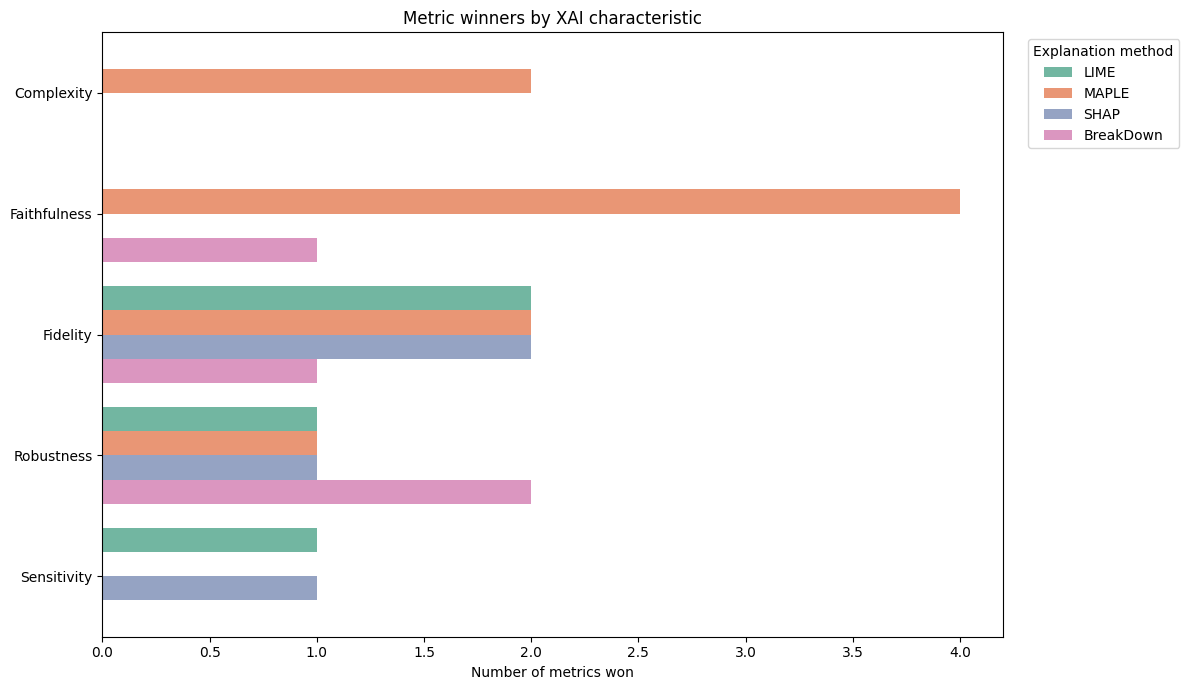

winner_by_mean,BreakDown,LIME,MAPLE,SHAP
characteristic,,,,
Complexity,0,0,2,0
Faithfulness,1,0,4,0
Fidelity,1,2,2,2
Robustness,2,1,1,1
Sensitivity,0,1,0,1


In [79]:
winner_characteristics = winners.copy()

winner_characteristics['characteristic'] = (
    winner_characteristics['metric']
    .map(METRIC_CHARACTERISTICS)
    .fillna("Other")
)

winner_counts = (
    winner_characteristics.groupby(
        ['characteristic', 'winner_by_mean'],
        as_index=False
    )
    .size()
    .rename(columns={"size": "metrics_won"})
)

characteristic_order = [
    "Complexity",
    "Faithfulness",
    "Fidelity",
    "Robustness",
    "Sensitivity"
]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=winner_counts,
    y='characteristic',
    x='metrics_won',
    hue='winner_by_mean',
    order=characteristic_order,
    hue_order=METHODS,
    palette="Set2",
    errorbar=None
)
plt.title("Metric winners by XAI characteristic")
plt.xlabel("Number of metrics won")
plt.ylabel("")
plt.legend(title="Explanation method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(
    winner_counts.pivot(index='characteristic', columns='winner_by_mean', values='metrics_won')
    .fillna(0)
    .astype(int)
)

## Global ranking heatmap

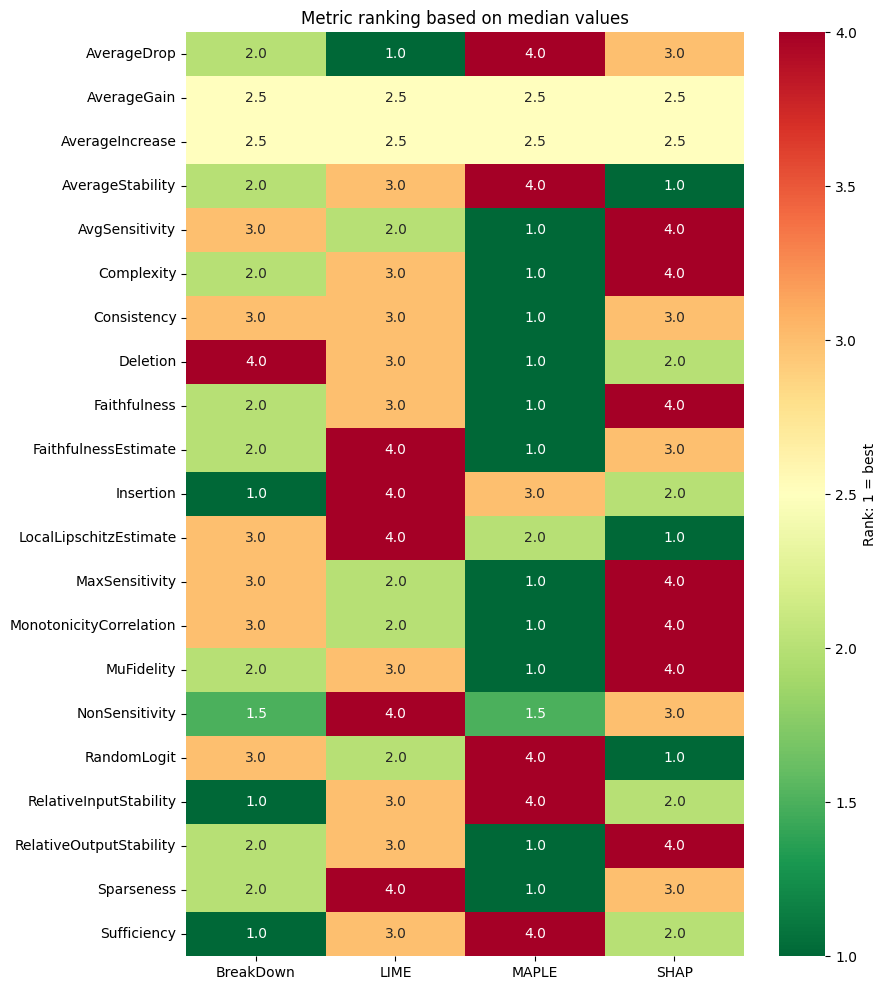

,average_rank
method,
MAPLE,2.023810
BreakDown,2.261905
SHAP,2.809524
LIME,2.904762


In [80]:
ranking_rows = []

for metric, group in method_stats.groupby('metric'):
    if metric in LOWER_IS_BETTER:
        ranked = group.assign(rank=group['median'].rank(method='average'))
    elif metric in HIGHER_IS_BETTER:
        ranked = group.assign(rank=(-group['median']).rank(method='average'))
    else:
        continue

    ranking_rows.append(ranked)

ranking_data = pd.concat(ranking_rows, ignore_index=True)

rank_matrix = ranking_data.pivot(
    index='metric',
    columns='method',
    values='rank'
)

rank_matrix = rank_matrix.loc[rank_matrix.mean(axis=1).sort_values().index]

plt.figure(figsize=(9, 12))
sns.heatmap(
    rank_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=1,
    vmax=4,
    cbar_kws={"label": "Rank: 1 = best"},
)
plt.title("Metric ranking based on median values")
plt.xlabel("")
plt.ylabel("")
plt.show()

display(rank_matrix.mean(axis=0).sort_values().rename("average_rank").to_frame())

## Results by dataset

dataset_name,AHU21,ARAMIS20,MetroPT3
metric,,,
AverageDrop,BreakDown,LIME,MAPLE
AverageGain,LIME,BreakDown,LIME
AverageIncrease,LIME,BreakDown,SHAP
AverageStability,SHAP,SHAP,SHAP
AvgSensitivity,LIME,LIME,SHAP
Complexity,MAPLE,MAPLE,LIME
Consistency,MAPLE,BreakDown,BreakDown
Deletion,SHAP,MAPLE,MAPLE
Faithfulness,MAPLE,MAPLE,MAPLE


dataset_name,AHU21,ARAMIS20,MetroPT3
metric,,,
AverageDrop,0.180446,0.274297,0.490564
AverageGain,0.243693,0.315386,0.241909
AverageIncrease,0.557143,0.473810,0.309524
AverageStability,0.064933,0.046307,0.092649
AvgSensitivity,1.117405,0.794093,1.318866
Complexity,1.853383,1.436522,1.240988
Consistency,0.747840,0.772451,0.729578
Deletion,0.515240,0.510826,0.501750
Faithfulness,0.083034,0.043391,0.005195


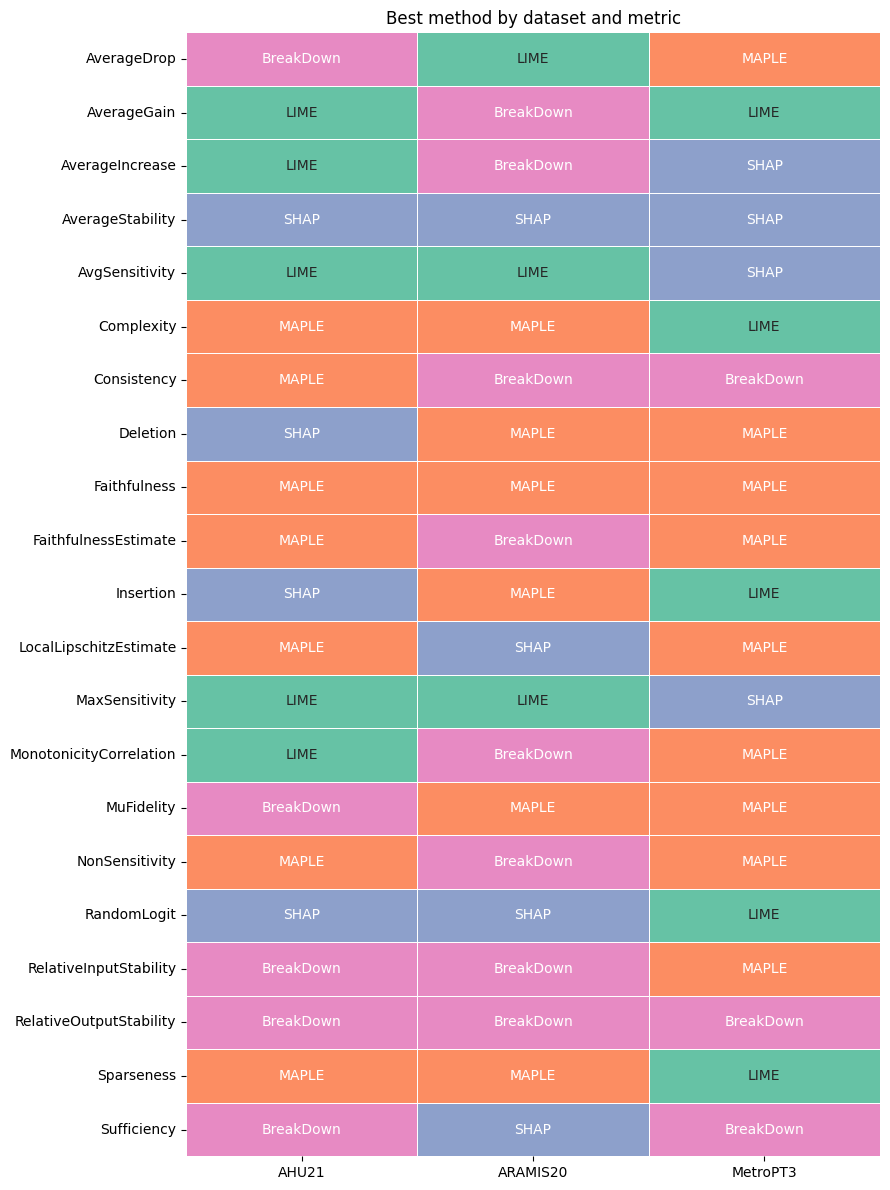

In [81]:
dataset_stats = pd.DataFrame(
    numeric_results.groupby(['dataset_name', 'metric', 'method'], as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median')
    )
)

dataset_winners = []

for dataset_name, dataset_group in dataset_stats.groupby('dataset_name'):
    for metric, metric_group in dataset_group.groupby('metric'):
        if metric in LOWER_IS_BETTER:
            winner = metric_group.loc[cast(int, metric_group['mean'].idxmin())]
        else:
            winner = metric_group.loc[cast(int, metric_group['mean'].idxmax())]

        dataset_winners.append(
            {
                "dataset_name": dataset_name,
                "metric": metric,
                "winner": winner['method'],
                "score": winner['mean']
            }
        )

dataset_winners = pd.DataFrame(dataset_winners)

display(dataset_winners.pivot(index="metric", columns="dataset_name", values="winner"))
display(dataset_winners.pivot(index="metric", columns="dataset_name", values="score"))

dataset_winner_matrix = dataset_winners.pivot(index='metric', columns='dataset_name', values='winner')

method_to_code = {method: index for index, method in enumerate(METHODS)}
winner_code_matrix = dataset_winner_matrix.apply(lambda column: column.map(method_to_code)).astype(float)

plt.figure(figsize=(9, 12))
sns.heatmap(
    winner_code_matrix,
    annot=dataset_winner_matrix,
    fmt="",
    cmap=sns.color_palette("Set2", len(METHODS)), # pyright: ignore[reportArgumentType]
    cbar=False,
    linewidths=0.5,
)
plt.title("Best method by dataset and metric")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Boolean and degenerate metrics

,metric,method,n,positives,positive_rate,positive_rate_pct
0,Completeness,BreakDown,1092,0,0.000000,0.000000
1,Completeness,LIME,1092,0,0.000000,0.000000
2,Completeness,MAPLE,1092,0,0.000000,0.000000
3,Completeness,SHAP,1092,0,0.000000,0.000000
4,Monotonicity,BreakDown,1092,948,0.868132,86.813187
5,Monotonicity,LIME,1092,947,0.867216,86.721612
6,Monotonicity,MAPLE,1092,947,0.867216,86.721612
7,Monotonicity,SHAP,1092,949,0.869048,86.904762
8,MonotonicityMetric,BreakDown,1092,57,0.052198,5.219780
9,MonotonicityMetric,LIME,1092,53,0.048535,4.853480


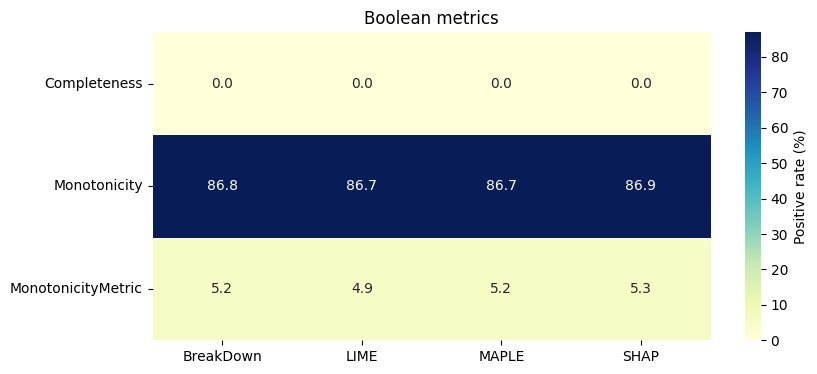

In [82]:
boolean_results = detailed_long[detailed_long['metric'].isin(BOOLEAN_METRICS)].copy()

normalised_values = boolean_results['value'].astype('string').str.strip().str.lower()

boolean_results['bool_value'] = normalised_values.map({"true": 1, "false": 0, "1": 1, "0": 0, "1.0": 1, "0.0": 0})

boolean_summary = (
    boolean_results.groupby(['metric', 'method'], as_index=False)
    .agg(
        n=("bool_value", "size"),
        positives=("bool_value", "sum"),
        positive_rate=("bool_value", "mean")
    )
)

boolean_summary['positive_rate_pct'] = 100 * boolean_summary['positive_rate']

display(boolean_summary.sort_values(['metric', 'method']))

boolean_pivot = boolean_summary.pivot(
    index='metric',
    columns='method',
    values='positive_rate_pct'
)

plt.figure(figsize=(9, 4))
sns.heatmap(
    boolean_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Positive rate (%)"}
)
plt.title("Boolean metrics")
plt.xlabel("")
plt.ylabel("")
plt.show()

## Final decision table

In [83]:
decision_table = pd.DataFrame(method_stats.pivot(index='metric', columns='method', values='median'))

decision_table['criterion'] = np.select(
    [decision_table.index.isin(LOWER_IS_BETTER), decision_table.index.isin(HIGHER_IS_BETTER)],
    ["lower is better", "higher is better"],
    default="review"
)

decision_table['best_method'] = pd.Series(
    [
        row[METHODS].astype(float).idxmin()
        if metric in LOWER_IS_BETTER
        else row[METHODS].astype(float).idxmax()
        for metric, row in decision_table.iterrows()
    ],
    index=decision_table.index,
    dtype='string'
)

display(decision_table)

method,BreakDown,LIME,MAPLE,SHAP,criterion,best_method
metric,,,,,,
AverageDrop,0.043597,0.019496,0.104716,0.052639,lower is better,LIME
AverageGain,0.000000,0.000000,0.000000,0.000000,higher is better,LIME
AverageIncrease,0.000000,0.000000,0.000000,0.000000,higher is better,LIME
AverageStability,0.057407,0.156928,0.307277,0.039265,lower is better,SHAP
AvgSensitivity,1.103769,1.060571,0.820476,1.132209,lower is better,MAPLE
Complexity,1.657404,1.709480,1.599622,1.717777,lower is better,MAPLE
Consistency,0.902439,0.902439,0.904762,0.902439,higher is better,MAPLE
Deletion,0.503334,0.496136,0.481659,0.488272,lower is better,MAPLE
Faithfulness,-0.089950,-0.193086,0.025697,-0.286544,higher is better,MAPLE


# Variability

In [84]:
EPSILON = 1e-12

def median_absolute_deviation(values):
    median = values.median()
    return np.median(np.abs(values - median))

def interquartile_range(values):
    return values.quantile(0.75) - values.quantile(0.25)

def iqr_outlier_rate(values):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        return 0.0

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return ((values < lower_bound) | (values > upper_bound)).mean()

## Global variavility per metric

In [85]:
global_metric_variability = (
    numeric_results.groupby('metric', as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median'),
        std=('numeric_value', 'std'),
        min=('numeric_value', 'min'),
        p05=('numeric_value', lambda x: x.quantile(0.05)),
        q1=('numeric_value', lambda x: x.quantile(0.25)),
        q3=('numeric_value', lambda x: x.quantile(0.75)),
        p95=('numeric_value', lambda x: x.quantile(0.95)),
        max=('numeric_value', 'max'),
        iqr=('numeric_value', interquartile_range),
        mad=('numeric_value', median_absolute_deviation),
        skewness=('numeric_value', 'skew'),
        iqr_outlier_rate=('numeric_value', iqr_outlier_rate)
    )
)

# Relative measures
global_metric_variability['central_span'] = (
    global_metric_variability['p95'] - global_metric_variability['p05']
)

global_metric_variability['mean_median_gap'] = (
    global_metric_variability['mean'] - global_metric_variability['median']
)

global_metric_variability['iqr_outlier_rate_pct'] = (
    100 * global_metric_variability['iqr_outlier_rate']
)

display(global_metric_variability.sort_values(['iqr_outlier_rate_pct', 'std'], ascending=[False, False]))

,metric,n,mean,median,std,min,p05,q1,q3,p95,max,iqr,mad,skewness,iqr_outlier_rate,central_span,mean_median_gap,iqr_outlier_rate_pct
16,RandomLogit,4368,8.244879e-01,0.993120,3.279576e-01,-7.137829e-01,0.007993,0.870090,0.999781,9.999963e-01,1.000000e+00,0.129691,0.006873,-1.825941,0.192766,9.920034e-01,-1.686322e-01,19.276557
18,RelativeOutputStability,2288,5.226726e+08,5252.178880,1.655833e+10,9.010076e-01,27.398325,265.496156,165423.907551,3.130192e+07,7.436560e+11,165158.411395,5217.245900,41.393167,0.189248,3.130189e+07,5.226673e+08,18.924825
17,RelativeInputStability,2309,2.261448e+02,0.045171,2.863656e+03,1.346755e-06,0.000049,0.000312,4.035669,5.201646e+01,1.083559e+05,4.035358,0.045150,26.497462,0.149848,5.201641e+01,2.260997e+02,14.984842
12,MaxSensitivity,4368,1.646622e+02,1.816000,3.523768e+03,6.196479e-02,0.541270,1.238953,2.701525,7.362728e+00,1.252843e+05,1.462572,0.675138,29.023096,0.119963,6.821457e+00,1.628462e+02,11.996337
3,AverageStability,4368,2.135992e-01,0.087061,3.191504e-01,0.000000e+00,0.004310,0.031382,0.268598,7.699422e-01,3.454678e+00,0.237216,0.073412,3.303086,0.085852,7.656319e-01,1.265386e-01,8.585165
4,AvgSensitivity,4368,1.149354e+02,1.018927,2.513987e+03,3.275383e-02,0.243656,0.608407,1.514277,3.472496e+00,9.097839e+04,0.905870,0.439169,29.450102,0.073031,3.228840e+00,1.139165e+02,7.303114
5,Complexity,4368,1.697602e+00,1.676691,5.632528e-01,-1.000089e-12,0.702159,1.422163,2.077475,2.535794e+00,2.763931e+00,0.655313,0.306730,-0.520614,0.030220,1.833635e+00,2.091119e-02,3.021978
11,LocalLipschitzEstimate,4368,5.382117e+00,4.397202,3.806597e+00,1.680686e-01,0.978014,2.364243,7.757600,1.263291e+01,3.137428e+01,5.393357,2.405185,1.111646,0.013736,1.165490e+01,9.849155e-01,1.373626
15,NonSensitivity,4368,3.292582e+00,3.000000,2.959620e+00,0.000000e+00,0.000000,1.000000,5.000000,1.000000e+01,1.400000e+01,4.000000,2.000000,1.111923,0.010531,1.000000e+01,2.925824e-01,1.053114
6,Consistency,4368,7.462527e-01,0.902439,2.582472e-01,0.000000e+00,0.243902,0.560976,0.920635,1.000000e+00,1.000000e+00,0.359659,0.097561,-1.011728,0.002518,7.560976e-01,-1.561863e-01,0.251832


## Global variability plots

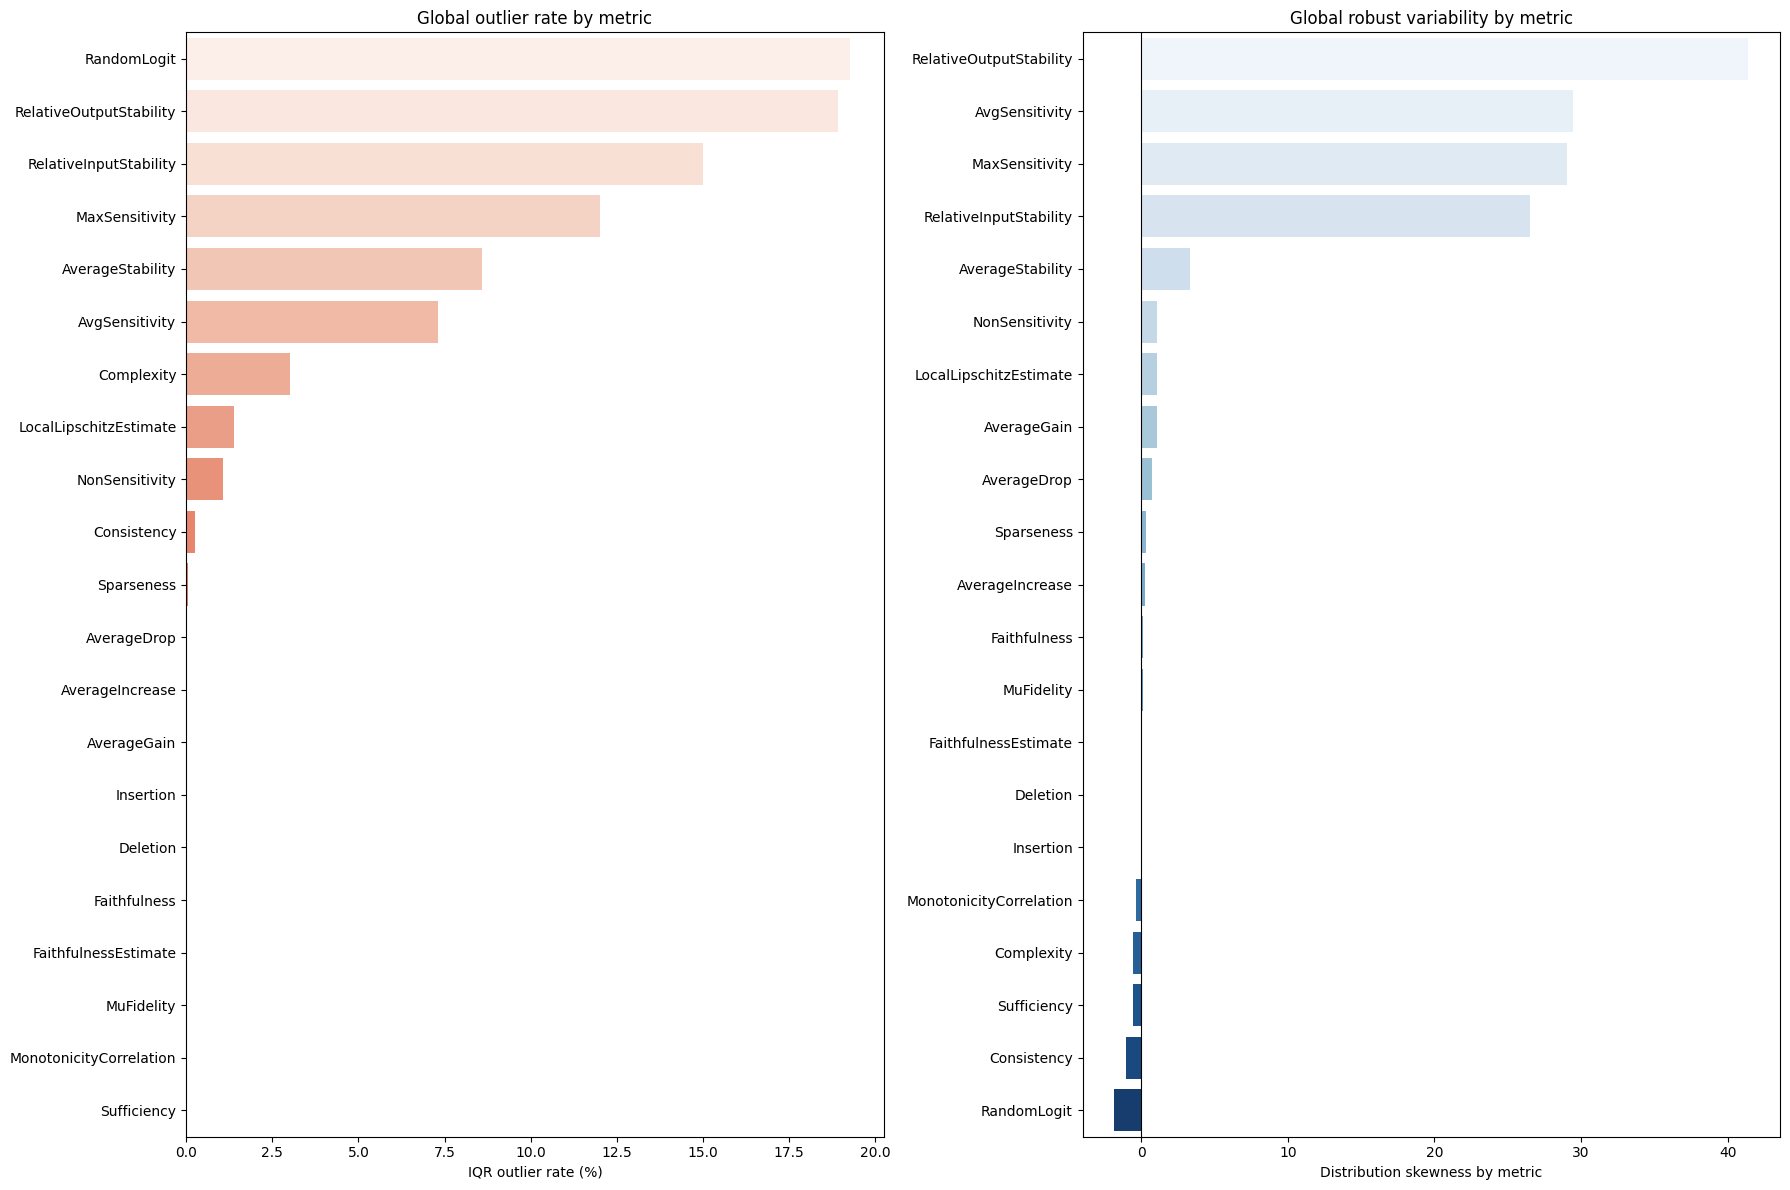

In [86]:
plot_variability = global_metric_variability.sort_values(
    'iqr_outlier_rate_pct',
    ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

sns.barplot(
    data=plot_variability,
    y='metric',
    x='iqr_outlier_rate_pct',
    hue='metric',
    palette='Reds',
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Global outlier rate by metric")
axes[0].set_xlabel("IQR outlier rate (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_variability.sort_values('skewness', ascending=False),
    y='metric',
    x='skewness',
    hue='metric',
    palette='Blues',
    legend=False,
    ax=axes[1],
)

axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Global robust variability by metric")
axes[1].set_xlabel("Distribution skewness by metric")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Global variance decomposition

In [87]:
def global_variance_decomposition(data, group_column):
    results = []

    for metric, subset in data.groupby('metric'):
        values = subset['numeric_value'].dropna()

        if len(values) < 2:
            continue

        grand_mean = values.mean()
        total_ss = ((values - grand_mean) ** 2).sum()

        if total_ss <= EPSILON:
            continue

        group_summary = (
            subset.groupby(group_column)['numeric_value']
            .agg(['count', 'mean', 'var'])
            .reset_index()
        )

        between_ss = (
            group_summary['count'] * (group_summary['mean'] - grand_mean) ** 2
        ).sum()

        within_ss = (
            (group_summary['count'] - 1) * group_summary['var'].fillna(0)
        ).sum()

        results.append(
            {
                "metric": metric,
                "grouping_factor": group_column,
                "total_variance": values.var(ddof=1),
                "between_variance_share": between_ss / total_ss,
                "within_variance_share": within_ss / total_ss,
                "n_groups": subset[group_column].nunique()
            }
        )

    return pd.DataFrame(results)

In [88]:
global_dataset_variance = global_variance_decomposition(numeric_results, 'dataset_name')

global_model_variance = global_variance_decomposition(numeric_results, 'model_name')

global_method_variance = global_variance_decomposition(numeric_results, 'method')

global_variance_results = pd.concat(
    [global_dataset_variance, global_model_variance, global_method_variance],
    ignore_index=True
)

display(global_variance_results.sort_values('between_variance_share', ascending=False))

,metric,grouping_factor,total_variance,between_variance_share,within_variance_share,n_groups
15,NonSensitivity,dataset_name,8.759350,0.502890,0.497110,3
53,LocalLipschitzEstimate,method,14.490180,0.337342,0.662658,4
27,Consistency,model_name,0.066692,0.336425,0.663575,6
26,Complexity,model_name,0.317254,0.285743,0.714257,6
45,AverageStability,method,0.101857,0.272209,0.727791,4
...,...,...,...,...,...,...
7,Deletion,dataset_name,0.103705,0.000589,0.999411,3
42,AverageDrop,method,0.140476,0.000400,0.999600,4
48,Consistency,method,0.066692,0.000183,0.999817,4
49,Deletion,method,0.103705,0.000109,0.999891,4


## Which factor explains global variability

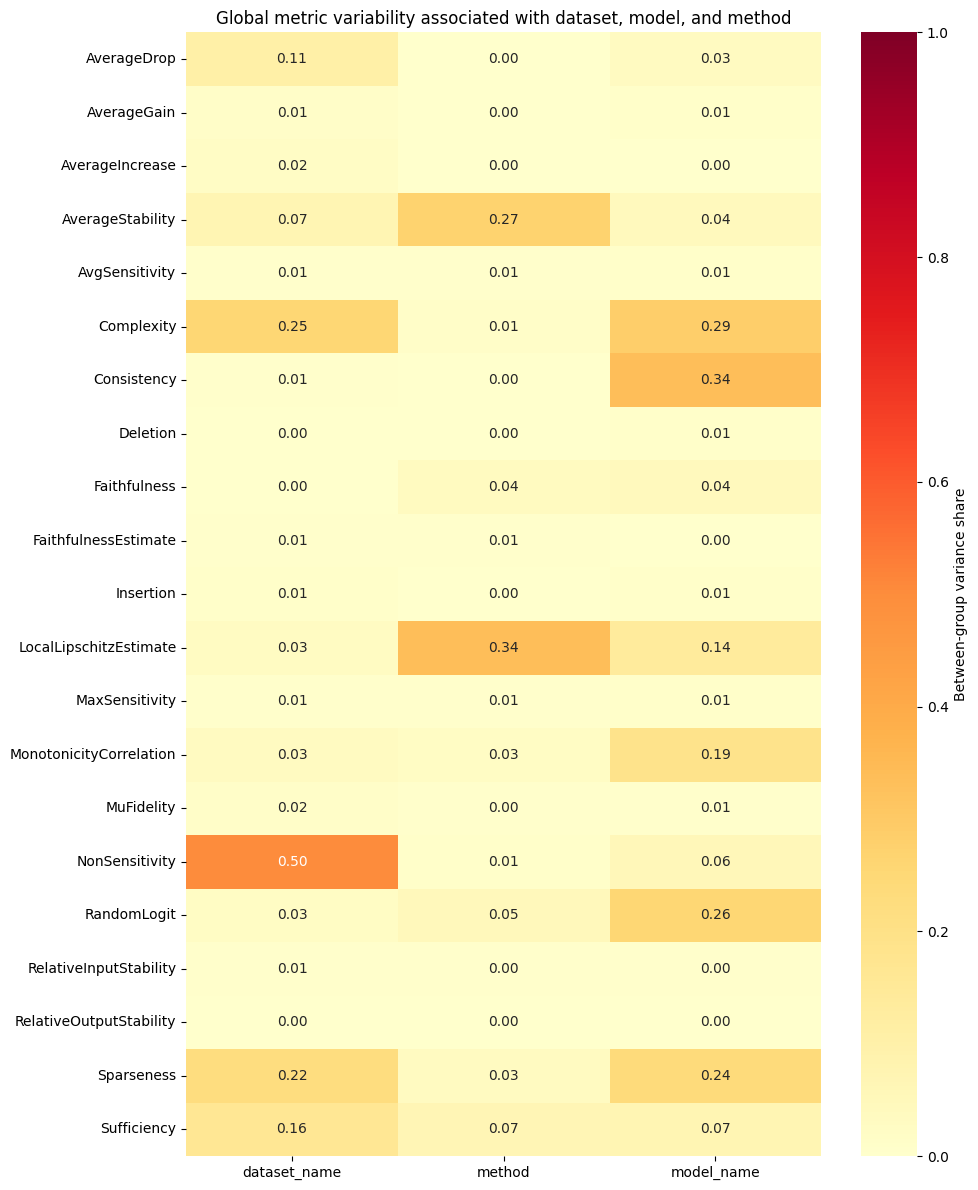

In [89]:
global_variance_matrix = global_variance_results.pivot(
    index='metric',
    columns='grouping_factor',
    values='between_variance_share'
)

plt.figure(figsize=(10, 12))

sns.heatmap(
    global_variance_matrix,
    annot=True,
    fmt=".2f",
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Between-group variance share"}
)

plt.title("Global metric variability associated with dataset, model, and method")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Metrics sensitivity

In [90]:
metric_sensitivity = (
    global_variance_results.pivot(
        index='metric',
        columns='grouping_factor',
        values='between_variance_share'
    )
    .rename(
        columns={
            "dataset_name": "dataset_sensitivity",
            "model_name": "model_sensitivity",
            "method": "method_sensitivity"
        }
    )
)

metric_sensitivity = metric_sensitivity.merge(
    global_metric_variability[
        [
            "metric",
            "iqr_outlier_rate_pct",
            "skewness",
            "mean_median_gap"
        ]
    ],
    left_index=True,
    right_on="metric",
    how="left"
).set_index("metric")

sensitivity_columns = ["dataset_sensitivity", "model_sensitivity", "method_sensitivity"]

metric_sensitivity['maximum_sensitivity'] = (
    metric_sensitivity[sensitivity_columns].max(axis=1)
)

metric_sensitivity['main_sensitivity_factor'] = (
    metric_sensitivity[sensitivity_columns]
    .idxmax(axis=1)
    .str.replace("_sensitivity", "", regex=False)
)

display(metric_sensitivity.sort_values('method_sensitivity', ascending=False))

,dataset_sensitivity,method_sensitivity,model_sensitivity,iqr_outlier_rate_pct,skewness,mean_median_gap,maximum_sensitivity,main_sensitivity_factor
metric,,,,,,,,
LocalLipschitzEstimate,0.029848,0.337342,0.137774,1.373626,1.111646,9.849155e-01,0.337342,method
AverageStability,0.070600,0.272209,0.044630,8.585165,3.303086,1.265386e-01,0.272209,method
Sufficiency,0.162860,0.068667,0.071266,0.000000,-0.521079,-1.740465e-01,0.162860,dataset
RandomLogit,0.027302,0.047090,0.257323,19.276557,-1.825941,-1.686322e-01,0.257323,model
Faithfulness,0.003229,0.035874,0.043877,0.000000,0.145493,3.087062e-03,0.043877,model
Sparseness,0.223012,0.034586,0.235316,0.045788,0.339946,2.395633e-02,0.235316,model
MonotonicityCorrelation,0.034071,0.025859,0.189833,0.000000,-0.329695,-3.726419e-02,0.189833,model
Complexity,0.254892,0.014475,0.285743,3.021978,-0.520614,2.091119e-02,0.285743,model
NonSensitivity,0.502890,0.009439,0.056105,1.053114,1.111923,2.925824e-01,0.502890,dataset


# Correlations

In [91]:
CORRELATION_METHOD = "spearman"
MIN_PAIRS = 30

correlation_input = numeric_results.copy()

# Average duplicate metric-observation-method records if any exist
metric_wide = pd.DataFrame(
    correlation_input.pivot_table(
        index=['dataset_name', 'model_name', 'observation', 'method'],
        columns='metric',
        values='numeric_value',
        aggfunc='mean'
    ).reset_index()
)

metric_columns = sorted(
    column
    for column in metric_wide.columns
    if column not in ['dataset_name', 'model_name', 'observation', 'method']
)

print(f"Rows available for correlation analysis: {len(metric_wide):,}")
print(f"Numeric metrics available: {len(metric_columns)}")
print(metric_columns)
display(metric_wide)

Rows available for correlation analysis: 4,368
Numeric metrics available: 21
['AverageDrop', 'AverageGain', 'AverageIncrease', 'AverageStability', 'AvgSensitivity', 'Complexity', 'Consistency', 'Deletion', 'Faithfulness', 'FaithfulnessEstimate', 'Insertion', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MuFidelity', 'NonSensitivity', 'RandomLogit', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']


metric,dataset_name,model_name,observation,method,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,BreakDown,0.000000,0.328120,1.0,0.084563,0.772246,2.233124,...,1.861340,1.507429,0.044118,0.084955,3.0,0.970922,NaN,NaN,0.530557,0.927273
1,AHU21,AutoEncoder,10163,LIME,0.000000,0.381495,1.0,0.443617,0.996399,2.322274,...,7.056067,1.930040,0.357843,-0.194770,3.0,0.974382,NaN,NaN,0.542530,0.904762
2,AHU21,AutoEncoder,10163,MAPLE,0.000000,0.181149,1.0,0.248567,0.267372,1.740961,...,2.410579,1.361618,0.232843,0.074178,2.0,0.999923,NaN,NaN,0.720109,0.000000
3,AHU21,AutoEncoder,10163,SHAP,0.000000,0.274779,1.0,0.041415,1.599045,2.389480,...,1.851138,3.593856,-0.181373,0.137052,3.0,0.328665,NaN,NaN,0.514415,0.942308
4,AHU21,AutoEncoder,10164,BreakDown,0.000000,0.331560,1.0,0.081238,0.831297,2.228982,...,1.696405,1.549898,0.058824,0.082384,3.0,0.972407,NaN,NaN,0.533332,0.927273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4363,MetroPT3,VAE,2020-08-30 08:30:00,SHAP,0.684132,0.000000,0.0,0.009490,1.725289,1.926630,...,1.421964,3.350384,-0.218846,-0.234344,2.0,0.519601,1.396620,3.801698e+05,0.441223,0.000000
4364,MetroPT3,VAE,2020-08-30 19:00:00,BreakDown,0.594771,0.000000,0.0,0.011430,2.722145,2.084353,...,1.124850,5.553715,0.090909,-0.453701,0.0,0.186463,0.000778,1.725704e+02,0.364733,0.947368
4365,MetroPT3,VAE,2020-08-30 19:00:00,LIME,0.768124,0.000000,0.0,0.262379,1.124256,0.853243,...,12.732899,2.185274,0.493991,-0.085606,4.0,0.979703,5.740700,1.461034e+06,0.794698,0.000000
4366,MetroPT3,VAE,2020-08-30 19:00:00,MAPLE,0.556925,0.000000,0.0,0.652771,1.539318,1.719236,...,6.081320,1.898262,-0.474166,-0.067724,2.0,0.363713,22.176199,5.878716e+06,0.555662,1.000000


In [92]:
def compute_correlation_matrix(data, metric_columns, method='spearman', min_pairs=30):
    """
    Returns:
        correlation_matrix: Pairwise correlation values.
        sample_size_matrix: Number of valid paired observations.
    """
    # Gets only the metric values
    metric_data = data[metric_columns]

    # notna() -> returns True and False if it is not nan
    # astype(int) -> transform the True/False to 1/0
    # .T -> matrix traspose
    # .dot(...) -> for every metric pair, sum the products
    sample_size_matrix = metric_data.notna().astype(int).T.dot(metric_data.notna().astype(int))

    # Calculate the correlation for every column pair
    correlation_matrix = metric_data.corr(method=method, min_periods=min_pairs)

    return correlation_matrix, sample_size_matrix

In [93]:
def correlation_pairs(correlation_matrix, sample_size_matrix, top_n=20):
    """
    Returns the strongest unique metric pairs by absolute correlation
    """
    correlation_matrix = correlation_matrix.rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    sample_size_matrix = sample_size_matrix.rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    # Mask of the correlation_matrix's upper triangle
    # k=1 excludes the diagonal
    upper_triangle = np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1)

    # Transform the matrix's useful part into a pairs table
    # .where(upper_triangle) -> apply the mask, the outer positions now are NaN
    # .stack() -> remove the NaN values and transform the matrix into a indexed series
    #
    #  ```
    #   metric_1     metric_2
    #   AverageDrop  Insertion    -0.72
    #                Complexity    0.15
    #   Insertion    Complexity   -0.08
    #  ```
    # 
    # .rename('correlation') -> rename the series' values' column
    # .reset_index() -> transform the metric_1 and metric_2 index into normal columns
    pairs = correlation_matrix.where(upper_triangle).stack().rename('correlation').reset_index()

    # Adds a column with the number of valid observations used on every correlation
    # .apply(...) -> executes lambda for every row from pairs
    # .loc[row[], row[]] -> search in the matrix the celd that corresponds to that pair
    pairs['n_pairs'] = pairs.apply(
        lambda row: sample_size_matrix.loc[row['metric_1'], row['metric_2']],
        axis=1
    )

    pairs['abs_correlation'] = pairs['correlation'].abs()

    # .dropna(subset['correlation']) -> remove any pair whose correlation is NaN
    # .sort_values() -> order the series
    # .head(top_n) -> get only the top_n pairs
    # .reset_index -> reset the index
    return (
        pairs.dropna(subset=['correlation'])
        .sort_values('abs_correlation', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [94]:
def plot_correlation_heatmap(correlation_matrix, title, figsize=(14, 12)):
    plt.figure(figsize=figsize)

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Correlation coefficient"},
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

In [95]:
from matplotlib.patches import Patch

CHARACTERISTIC_ORDER = [
    "Complexity",
    "Faithfulness",
    "Fidelity",
    "Robustness",
    "Sensitivity",
    "Other",
]

CHARACTERISTIC_COLORS = {
    "Complexity": "#54A24B",
    "Faithfulness": "#4C78A8",
    "Fidelity": "#F58518",
    "Robustness": "#B279A2",
    "Sensitivity": "#E45756",
    "Other": "#8C8C8C",
}

def plot_grouped_correlation_heatmap(
    correlation_matrix,
    metric_characteristics,
    title,
    figsize=(16, 14),
):
    ordered_metrics = sorted(
        correlation_matrix.index,
        key=lambda metric: (
            CHARACTERISTIC_ORDER.index(
                metric_characteristics.get(metric, "Other")
            ),
            metric,
        ),
    )

    ordered_correlation = correlation_matrix.loc[
        ordered_metrics,
        ordered_metrics,
    ]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        ordered_correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Spearman correlation coefficient"},
        ax=ax,
    )

    for label in ax.get_xticklabels():
        metric = label.get_text()
        characteristic = metric_characteristics.get(metric, "Other")
        label.set_color(CHARACTERISTIC_COLORS[characteristic])

    for label in ax.get_yticklabels():
        metric = label.get_text()
        characteristic = metric_characteristics.get(metric, "Other")
        label.set_color(CHARACTERISTIC_COLORS[characteristic])

    previous_characteristic = metric_characteristics.get(
        ordered_metrics[0],
        "Other",
    )

    for position, metric in enumerate(ordered_metrics[1:], start=1):
        current_characteristic = metric_characteristics.get(metric, "Other")

        if current_characteristic != previous_characteristic:
            ax.axhline(position, color="black", linewidth=2)
            ax.axvline(position, color="black", linewidth=2)

        previous_characteristic = current_characteristic

    present_characteristics = {
        metric_characteristics.get(metric, "Other")
        for metric in ordered_metrics
    }

    legend_handles = [
        Patch(
            color=CHARACTERISTIC_COLORS[characteristic],
            label=characteristic,
        )
        for characteristic in CHARACTERISTIC_ORDER
        if characteristic in present_characteristics
    ]

    ax.legend(
        handles=legend_handles,
        title="Metric characteristic",
        bbox_to_anchor=(1.30, 1),
        loc="upper left",
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [96]:
def plot_grouped_std_heatmap(
    std_matrix,
    metric_characteristics,
    title,
    figsize=(16, 14),
):
    ordered_metrics = sorted(
        std_matrix.index,
        key=lambda metric: (
            CHARACTERISTIC_ORDER.index(
                metric_characteristics.get(metric, "Other")
            ),
            metric,
        ),
    )

    ordered_std = std_matrix.loc[
        ordered_metrics,
        ordered_metrics,
    ]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        ordered_std,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        vmin=0,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "Standard deviation of correlation"
        },
        ax=ax,
    )

    for label in ax.get_xticklabels():
        characteristic = metric_characteristics.get(
            label.get_text(),
            "Other",
        )
        label.set_color(CHARACTERISTIC_COLORS[characteristic])

    for label in ax.get_yticklabels():
        characteristic = metric_characteristics.get(
            label.get_text(),
            "Other",
        )
        label.set_color(CHARACTERISTIC_COLORS[characteristic])

    previous_characteristic = metric_characteristics.get(
        ordered_metrics[0],
        "Other",
    )

    for position, metric in enumerate(ordered_metrics[1:], start=1):
        current_characteristic = metric_characteristics.get(
            metric,
            "Other",
        )

        if current_characteristic != previous_characteristic:
            ax.axhline(position, color="black", linewidth=2)
            ax.axvline(position, color="black", linewidth=2)

        previous_characteristic = current_characteristic

    present_characteristics = {
        metric_characteristics.get(metric, "Other")
        for metric in ordered_metrics
    }

    legend_handles = [
        Patch(
            color=CHARACTERISTIC_COLORS[characteristic],
            label=characteristic,
        )
        for characteristic in CHARACTERISTIC_ORDER
        if characteristic in present_characteristics
    ]

    ax.legend(
        handles=legend_handles,
        title="Metric characteristic",
        bbox_to_anchor=(1.30, 1),
        loc="upper left",
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## General correlation analysis

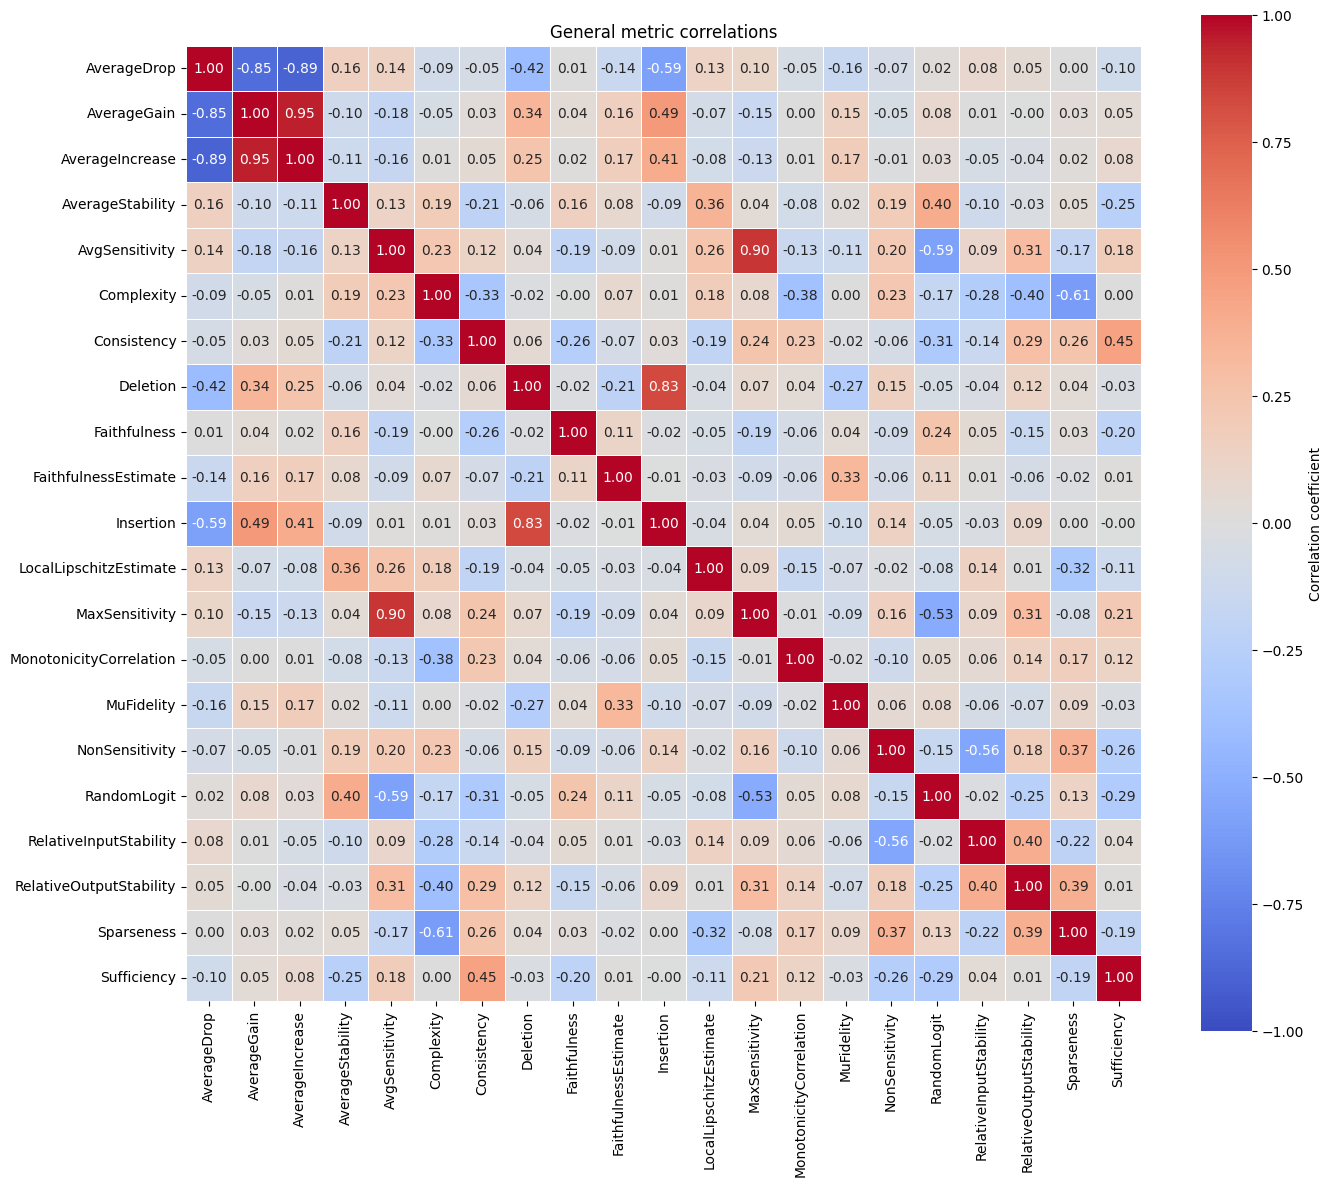

,metric_1,metric_2,correlation,n_pairs,abs_correlation
0,AverageGain,AverageIncrease,0.947551,4368,0.947551
1,AvgSensitivity,MaxSensitivity,0.895338,4368,0.895338
2,AverageDrop,AverageIncrease,-0.892101,4368,0.892101
3,AverageDrop,AverageGain,-0.845311,4368,0.845311
4,Deletion,Insertion,0.834956,4368,0.834956
5,Complexity,Sparseness,-0.613995,4368,0.613995
6,AverageDrop,Insertion,-0.590165,4368,0.590165
7,AvgSensitivity,RandomLogit,-0.585437,4368,0.585437
8,NonSensitivity,RelativeInputStability,-0.560622,2309,0.560622
9,MaxSensitivity,RandomLogit,-0.530163,4368,0.530163


In [97]:
general_pair_tables = []

correlation_matrix, sample_size_matrix = compute_correlation_matrix(
    metric_wide,
    metric_columns,
    method=CORRELATION_METHOD,
    min_pairs=MIN_PAIRS
)

general_correlations = {
    "correlation": correlation_matrix,
    "n_pairs": sample_size_matrix
}

# Get and format the 20 highest correlations
pairs = correlation_pairs(
    correlation_matrix,
    sample_size_matrix,
    top_n=20
)

general_pair_tables.append(pairs)

plot_correlation_heatmap(
    correlation_matrix,
    title=f"General metric correlations"
)

general_top_pairs = pd.concat(
    general_pair_tables,
    ignore_index=True
).sort_values(
    ['abs_correlation'],
    ascending=False
)

display(general_top_pairs)

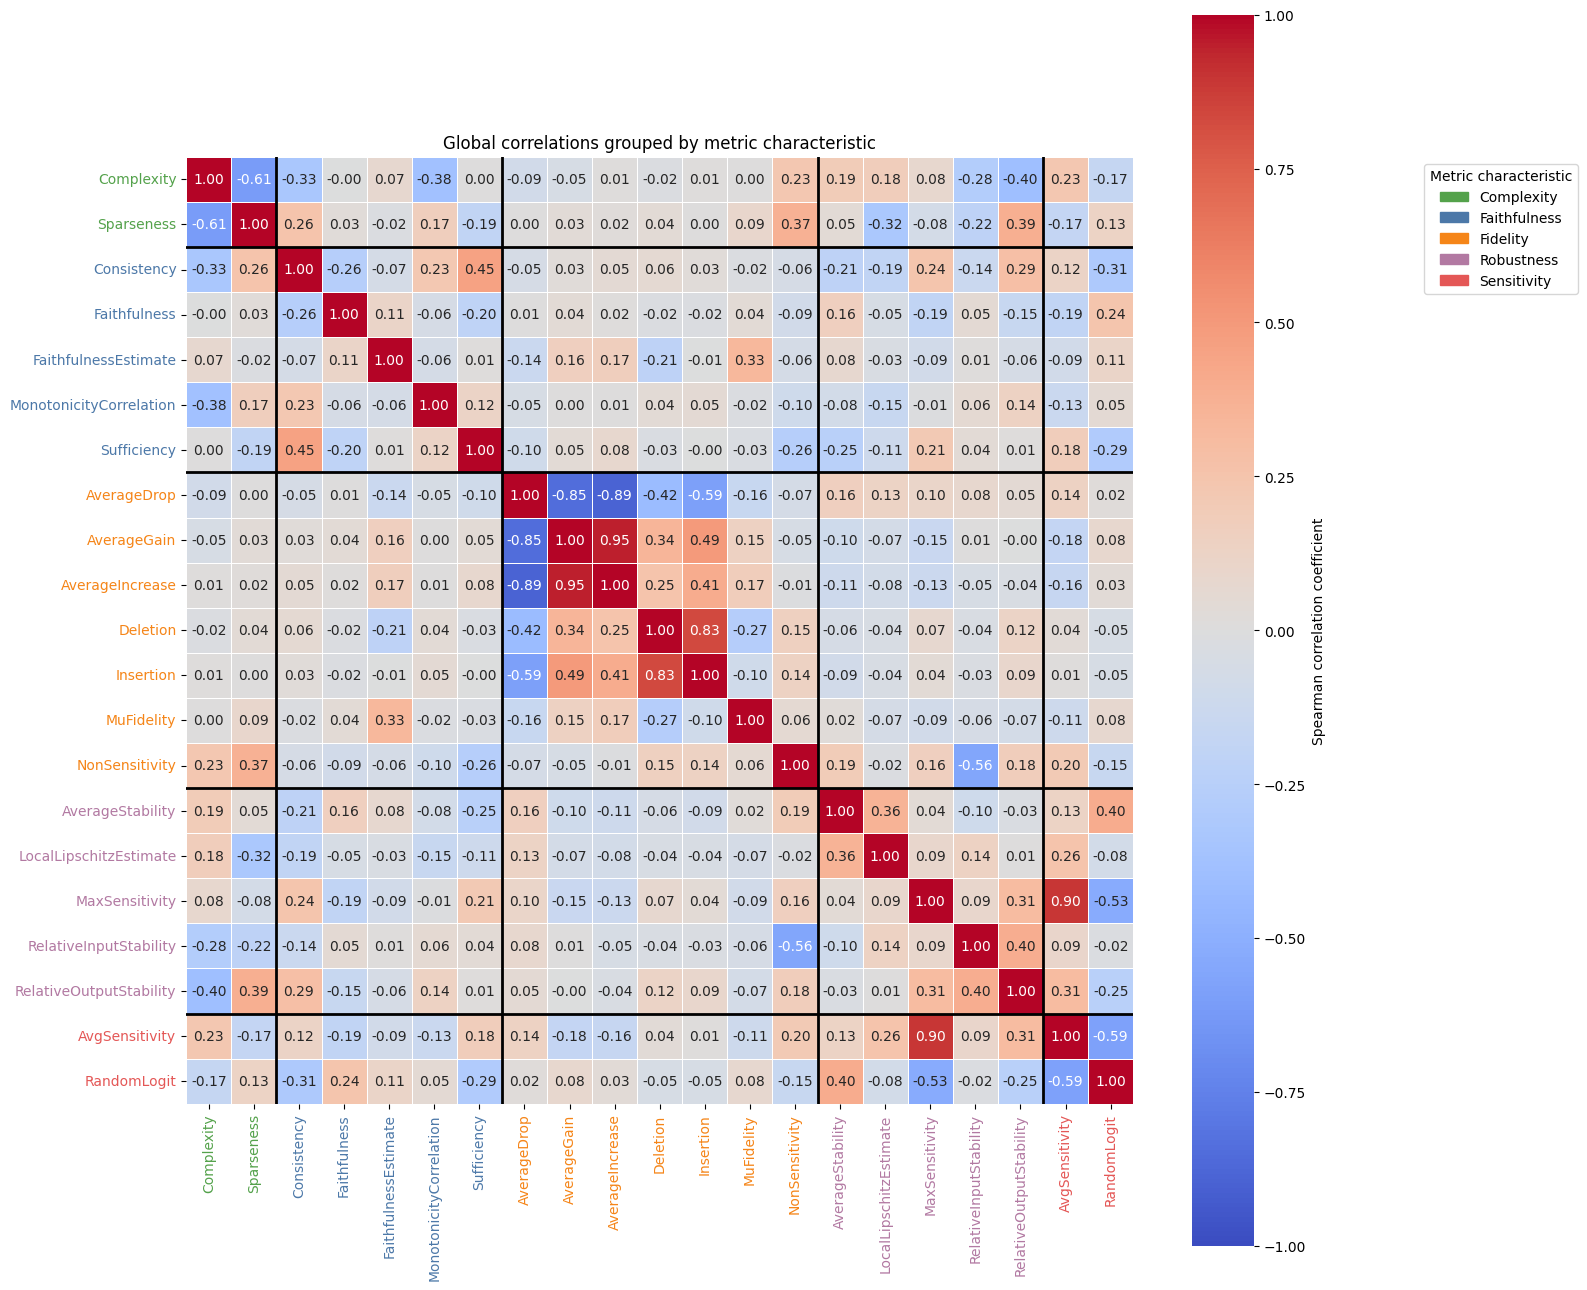

In [98]:
available_metrics = correlation_matrix.index.tolist()

metric_characteristics = {
    metric: METRIC_CHARACTERISTICS.get(metric, "Other")
    for metric in available_metrics
}

unclassified_metrics = [
    metric
    for metric, characteristic in metric_characteristics.items()
    if characteristic == "Other"
]

if unclassified_metrics:
    print("Metrics without an assigned characteristic:", unclassified_metrics)

plot_grouped_correlation_heatmap(
    correlation_matrix=correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Global correlations grouped by metric characteristic",
)

In [99]:
stratum_correlations = {}
all_stratum_pairs = []

group_columns = ["dataset_name", "model_name", "method"]

for (dataset_name, model_name, method), stratum_data in metric_wide.groupby(
    group_columns
):
    correlation_matrix, sample_size_matrix = compute_correlation_matrix(
        stratum_data,
        metric_columns,
        method=CORRELATION_METHOD,
        min_pairs=MIN_PAIRS,
    )

    stratum_id = f"{dataset_name} | {model_name} | {method}"

    stratum_correlations[stratum_id] = {
        "correlation": correlation_matrix,
        "n_pairs": sample_size_matrix,
        "dataset_name": dataset_name,
        "model_name": model_name,
        "method": method,
    }

    # Use every valid metric pair, not only the top 20.
    pairs = correlation_pairs(
        correlation_matrix,
        sample_size_matrix,
        top_n=None,
    )

    pairs['dataset_name'] = dataset_name
    pairs['model_name'] = model_name
    pairs['method'] = method
    pairs['stratum_id'] = stratum_id

    all_stratum_pairs.append(pairs)

all_stratum_pairs = pd.concat(
    all_stratum_pairs,
    ignore_index=True,
)

display(all_stratum_pairs.head())

conditional_correlation_summary = (
    all_stratum_pairs
    .groupby(['metric_1', 'metric_2'], as_index=False)
    .agg(
        strata_present=('stratum_id', 'nunique'),
        mean_correlation=('correlation', 'mean'),
        std_correlation=('correlation', 'std'),
        min_correlation=('correlation', 'min'),
        max_correlation=('correlation', 'max'),
        mean_abs_correlation=('abs_correlation', 'mean'),
        std_abs_correlation=('abs_correlation', 'std'),
        mean_n_pairs=('n_pairs', 'mean'),
    )
)

conditional_correlation_summary = conditional_correlation_summary.sort_values(
    ['mean_abs_correlation', 'std_correlation'],
    ascending=[False, True],
)

display(conditional_correlation_summary.head(30))

,metric_1,metric_2,correlation,n_pairs,abs_correlation,dataset_name,model_name,method,stratum_id
0,Complexity,Sparseness,-0.971796,70,0.971796,AHU21,AutoEncoder,BreakDown,AHU21 | AutoEncoder | BreakDown
1,AvgSensitivity,MaxSensitivity,0.950590,70,0.950590,AHU21,AutoEncoder,BreakDown,AHU21 | AutoEncoder | BreakDown
2,AverageGain,AverageIncrease,0.931381,70,0.931381,AHU21,AutoEncoder,BreakDown,AHU21 | AutoEncoder | BreakDown
3,AverageDrop,AverageIncrease,-0.920040,70,0.920040,AHU21,AutoEncoder,BreakDown,AHU21 | AutoEncoder | BreakDown
4,AvgSensitivity,RandomLogit,-0.876336,70,0.876336,AHU21,AutoEncoder,BreakDown,AHU21 | AutoEncoder | BreakDown


,metric_1,metric_2,strata_present,mean_correlation,std_correlation,min_correlation,max_correlation,mean_abs_correlation,std_abs_correlation,mean_n_pairs
103,Complexity,Sparseness,71,-0.981377,0.019186,-0.998541,-0.872161,0.981377,0.019186,60.929577
20,AverageGain,AverageIncrease,72,0.946140,0.036128,0.804722,0.990517,0.946140,0.036128,60.666667
1,AverageDrop,AverageIncrease,72,-0.875789,0.067338,-0.979282,-0.714740,0.875789,0.067338,60.666667
81,AvgSensitivity,MaxSensitivity,72,0.866795,0.174581,0.061016,0.990276,0.866795,0.174581,60.666667
0,AverageDrop,AverageGain,72,-0.826683,0.044146,-0.889825,-0.707961,0.826683,0.044146,60.666667
121,Deletion,Insertion,72,0.672334,0.331942,-0.313832,0.987788,0.695436,0.279538,60.666667
177,MaxSensitivity,RandomLogit,72,-0.570409,0.416876,-0.968332,0.614872,0.655544,0.260660,60.666667
85,AvgSensitivity,RandomLogit,72,-0.543490,0.439919,-0.977500,0.746759,0.624699,0.311970,60.666667
57,AverageStability,AvgSensitivity,72,0.420717,0.510681,-0.840574,0.972881,0.598094,0.278451,60.666667
46,AverageIncrease,Insertion,72,0.370865,0.513187,-0.847702,0.866114,0.571740,0.267110,60.666667


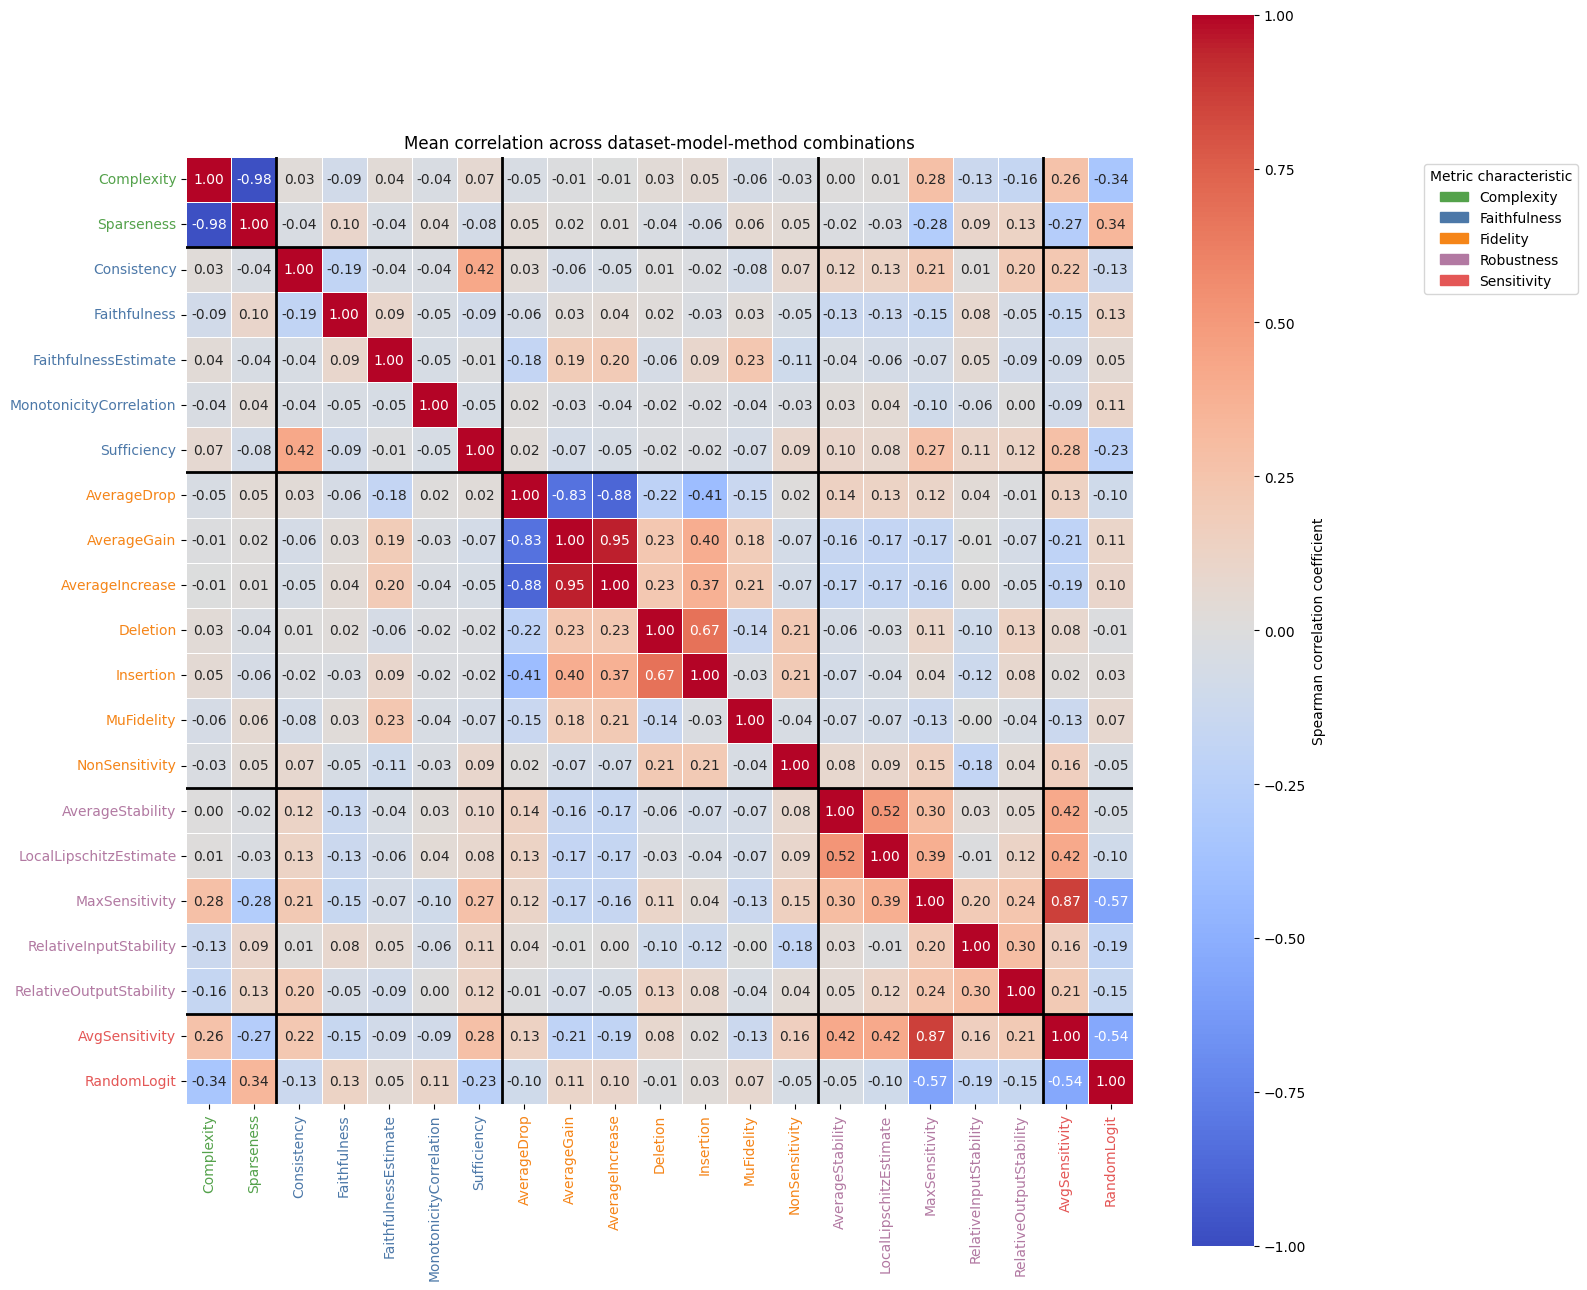

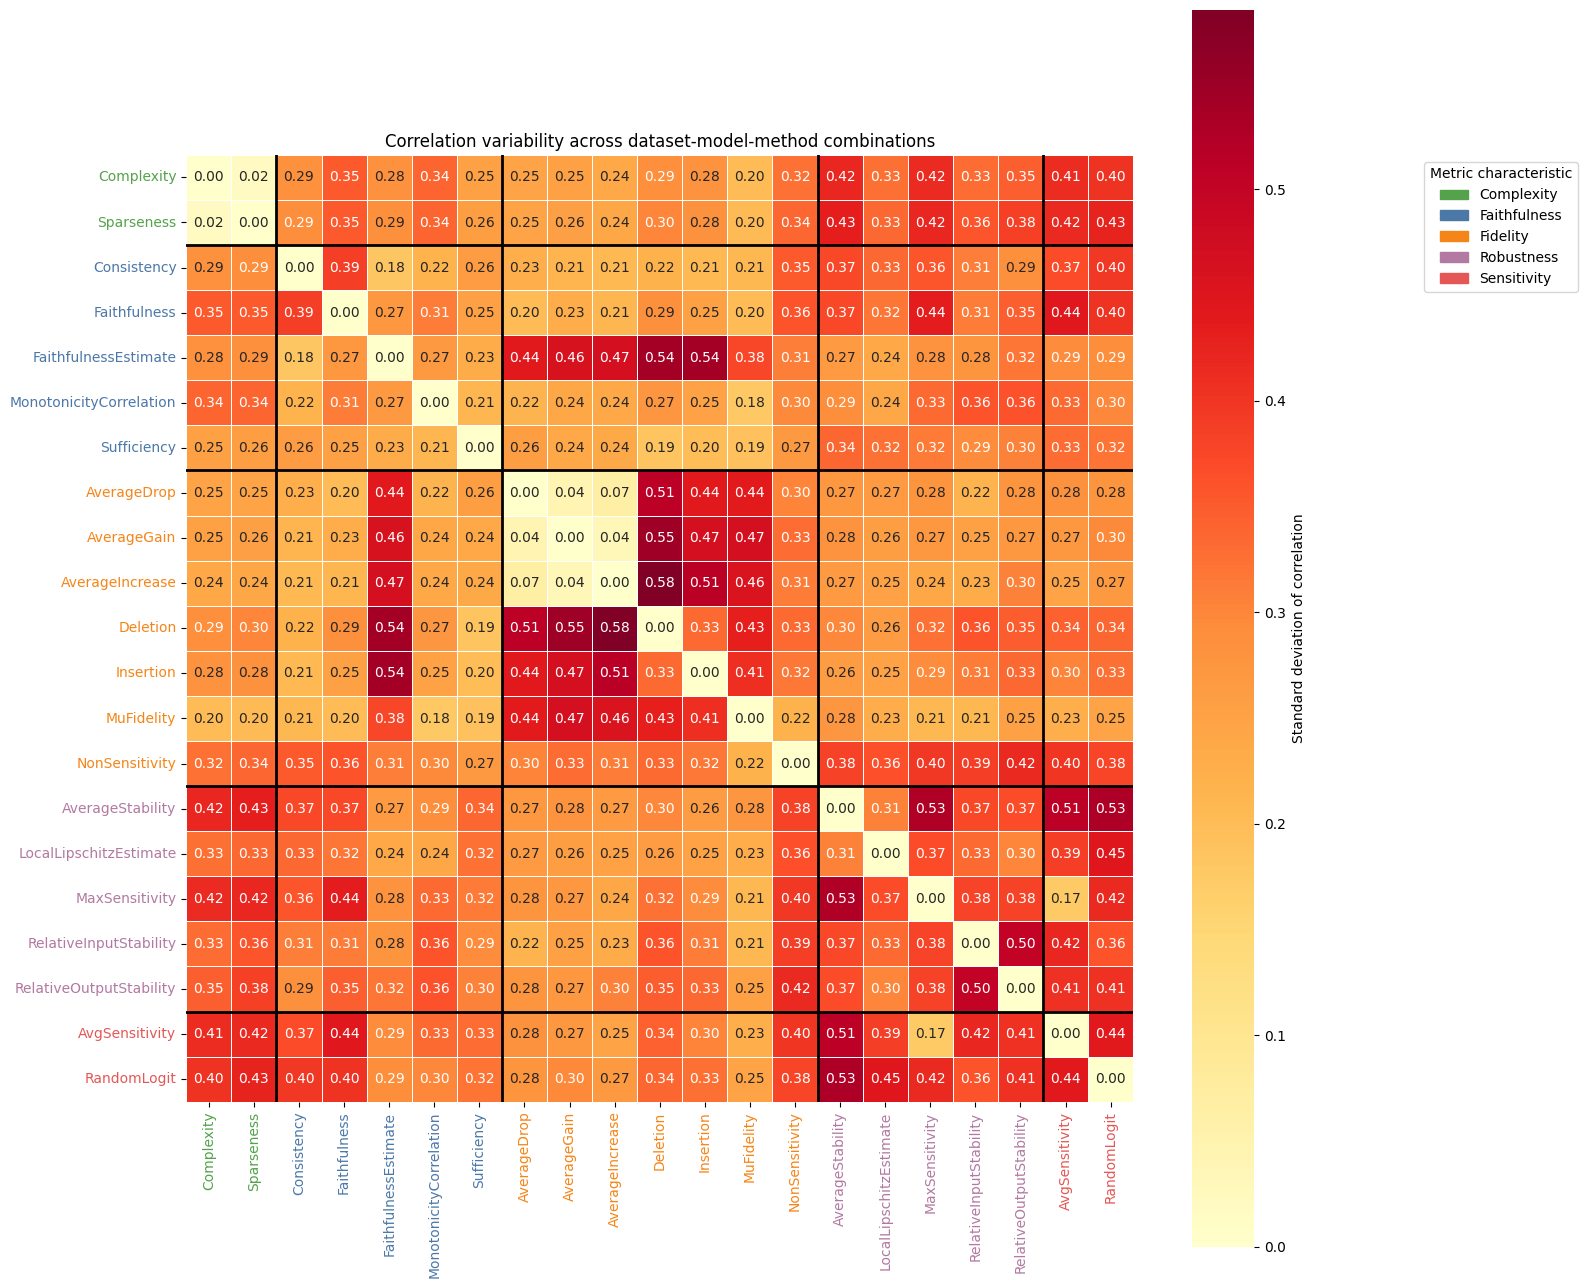

In [100]:
stacked_stratum_correlations = pd.concat(
    {
        stratum_id: results["correlation"]
        for stratum_id, results in stratum_correlations.items()
    },
    names=["stratum", "metric"],
)

mean_conditional_correlation_matrix = (
    stacked_stratum_correlations
    .groupby(level="metric")
    .mean()
)

std_conditional_correlation_matrix = (
    stacked_stratum_correlations
    .groupby(level="metric")
    .std()
)

plot_grouped_correlation_heatmap(
    correlation_matrix=mean_conditional_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Mean correlation across dataset-model-method combinations",
)

plot_grouped_std_heatmap(
    std_matrix=std_conditional_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Correlation variability across dataset-model-method combinations",
)

## Correlation by method

In [101]:
method_correlations = {}
method_pair_tables = []

for method in METHODS:
    method_data = metric_wide[metric_wide['method'] == method]

    correlation_matrix, sample_size_matrix = compute_correlation_matrix(
        method_data,
        metric_columns,
        method=CORRELATION_METHOD,
        min_pairs=MIN_PAIRS
    )

    method_correlations[method] = {
        "correlation": correlation_matrix,
        "n_pairs": sample_size_matrix
    }

    # Get and format the 20 highest correlations
    pairs = correlation_pairs(
        correlation_matrix,
        sample_size_matrix,
        top_n=20
    )

    pairs['method'] = method
    method_pair_tables.append(pairs)

    # plot_correlation_heatmap(
    #     correlation_matrix,
    #     title=f"General metric correlations - {method}"
    # )

# general_top_pairs = pd.concat(
#     method_pair_tables,
#     ignore_index=True
# ).sort_values(
#     ['abs_correlation', 'method'],
#     ascending=[False, True]
# )

# display(general_top_pairs)

all_method_pairs = []

for method, results in method_correlations.items():
    correlation_matrix = results['correlation'].rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    sample_size_matrix = results['n_pairs'].rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    upper_triangle = np.triu(
        np.ones(correlation_matrix.shape, dtype=bool),
        k=1
    )

    method_pairs = (
        correlation_matrix
        .where(upper_triangle)
        .stack()
        .rename('correlation')
        .reset_index()
    )

    method_pairs['n_pairs'] = method_pairs.apply(
        lambda row: sample_size_matrix.loc[
            row['metric_1'],
            row['metric_2']
        ],
        axis=1
    )

    method_pairs['method'] = method
    method_pairs['abs_correlation'] = method_pairs['correlation'].abs()

    all_method_pairs.append(method_pairs)

all_method_pairs = pd.concat(all_method_pairs, ignore_index=True)

correlation_summary = (
    all_method_pairs
    .groupby(['metric_1', 'metric_2'], as_index=False)
    .agg(
        # methods_present=('method', 'nunique'),
        mean_correlation=('correlation', 'mean'),
        std_correlation=('correlation', 'std'),
        min_correlation=('correlation', 'min'),
        max_correlation=('correlation', 'max'),
        mean_abs_correlation=('abs_correlation', 'mean'),
        std_abs_correlation=('abs_correlation', 'std'),
        mean_n_pairs=('n_pairs', 'mean'),
    )
)

correlation_summary = correlation_summary.sort_values(
    ['mean_abs_correlation', 'std_correlation'],
    ascending=[False, True]
)

display(correlation_summary.head(30))

,metric_1,metric_2,mean_correlation,std_correlation,min_correlation,max_correlation,mean_abs_correlation,std_abs_correlation,mean_n_pairs
23,AverageGain,AverageIncrease,0.947206,0.008187,0.938704,0.958379,0.947206,0.008187,1092.00
96,AvgSensitivity,MaxSensitivity,0.906675,0.025331,0.869200,0.924217,0.906675,0.025331,1092.00
2,AverageDrop,AverageIncrease,-0.891499,0.012771,-0.904779,-0.874077,0.891499,0.012771,1092.00
1,AverageDrop,AverageGain,-0.844355,0.004848,-0.849320,-0.837698,0.844355,0.004848,1092.00
157,Deletion,Insertion,0.836022,0.030856,0.812225,0.878763,0.836022,0.030856,1092.00
10,AverageDrop,Insertion,-0.589534,0.025073,-0.611718,-0.559786,0.589534,0.025073,1092.00
124,Complexity,Sparseness,-0.577657,0.085135,-0.693521,-0.499784,0.577657,0.085135,1092.00
332,NonSensitivity,RelativeInputStability,-0.567040,0.059548,-0.641637,-0.506214,0.567040,0.059548,577.25
268,MaxSensitivity,RandomLogit,-0.539589,0.299174,-0.815790,-0.225284,0.539589,0.299174,1092.00
100,AvgSensitivity,RandomLogit,-0.499322,0.259358,-0.722658,-0.219385,0.499322,0.259358,1092.00


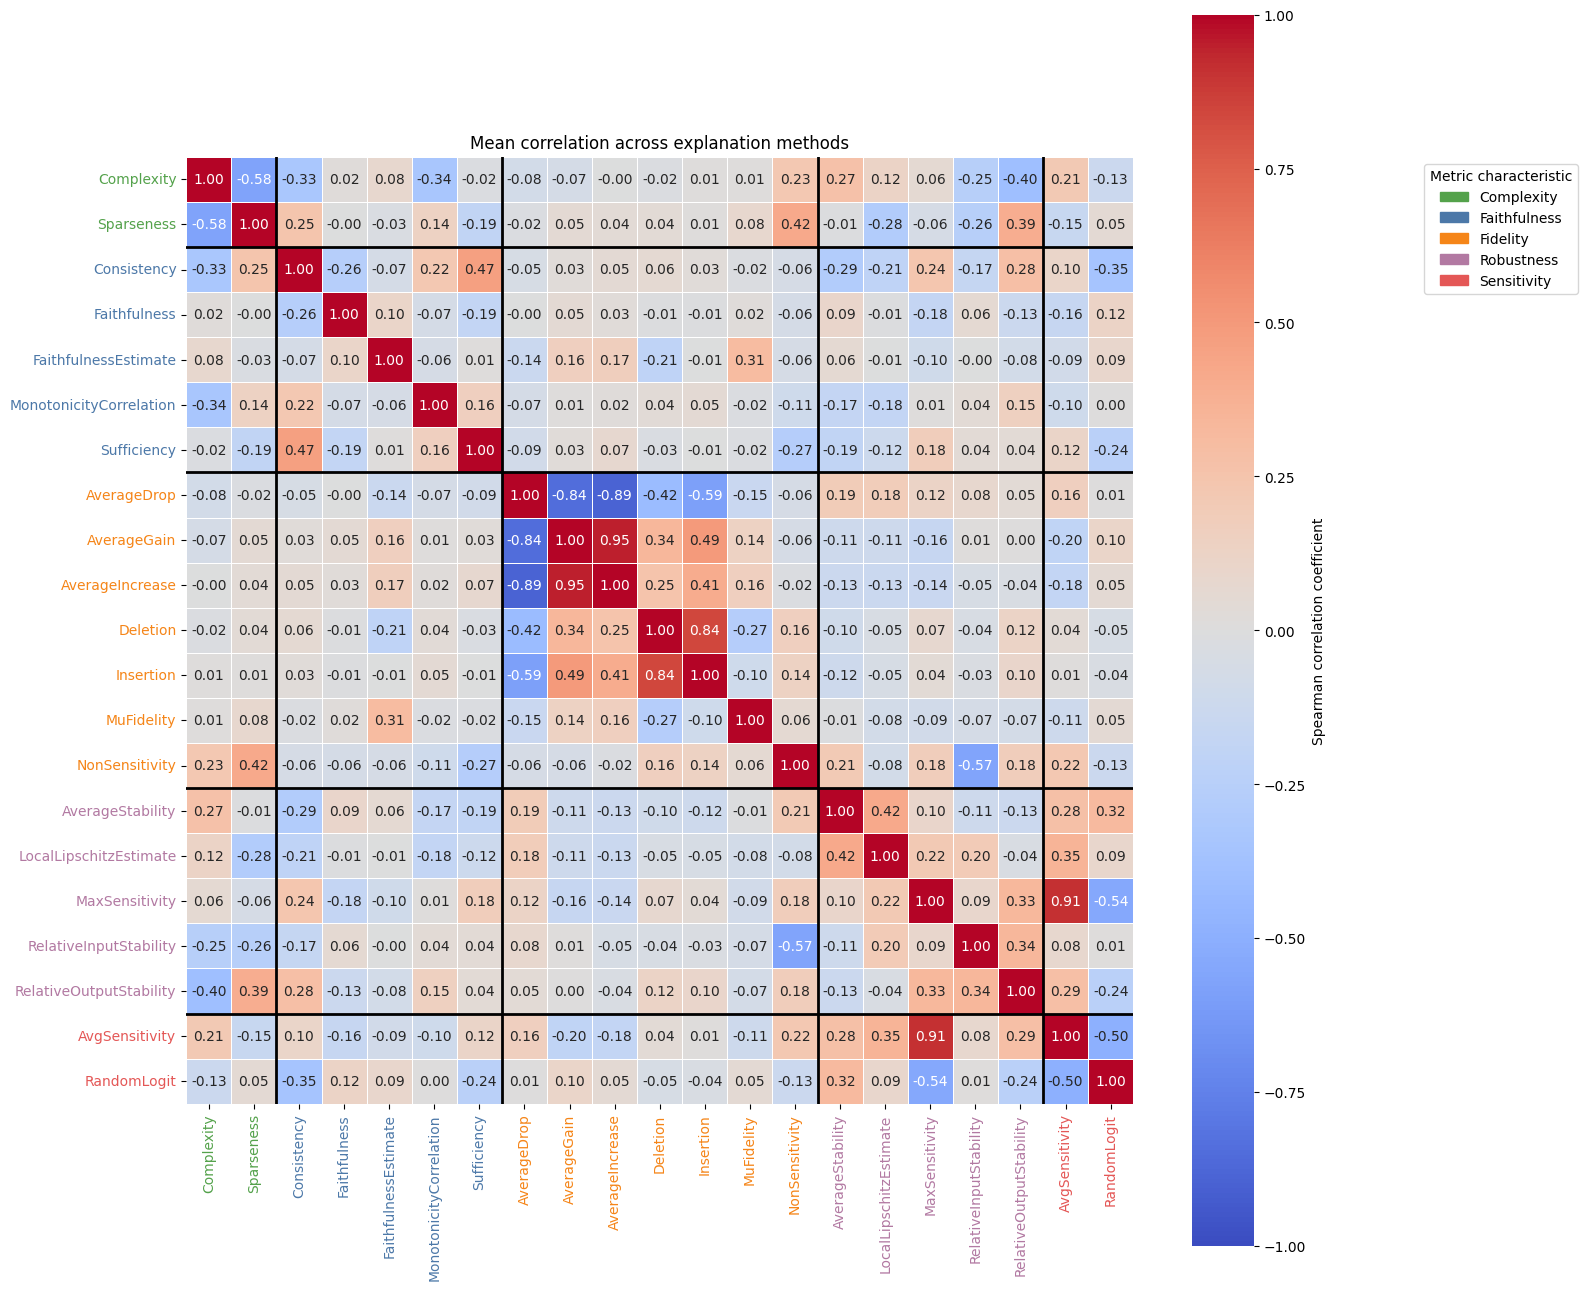

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,1.000000,-0.844355,-0.891499,0.190994,0.163017,-0.080476,-0.054371,-0.418041,-0.001668,-0.136357,...,0.181204,0.121292,-0.066449,-0.145212,-0.060857,0.007769,0.080476,0.045529,-0.021968,-0.087648
AverageGain,-0.844355,1.000000,0.947206,-0.113835,-0.202106,-0.065715,0.027399,0.343418,0.052404,0.157726,...,-0.109725,-0.161864,0.012930,0.137678,-0.057184,0.101712,0.012913,0.002763,0.050216,0.029956
AverageIncrease,-0.891499,0.947206,1.000000,-0.127998,-0.181859,-0.000275,0.049879,0.253840,0.025081,0.166406,...,-0.134840,-0.142391,0.016250,0.163868,-0.016584,0.050174,-0.049511,-0.036295,0.040571,0.074582
AverageStability,0.190994,-0.113835,-0.127998,1.000000,0.276138,0.267665,-0.285847,-0.097293,0.094161,0.059020,...,0.415555,0.098203,-0.174137,-0.010443,0.206693,0.317912,-0.111895,-0.131102,-0.012553,-0.191157
AvgSensitivity,0.163017,-0.202106,-0.181859,0.276138,1.000000,0.211663,0.103903,0.044272,-0.158090,-0.091931,...,0.353203,0.906675,-0.101672,-0.110412,0.219473,-0.499322,0.079490,0.287762,-0.154426,0.117120
Complexity,-0.080476,-0.065715,-0.000275,0.267665,0.211663,1.000000,-0.329525,-0.020199,0.016852,0.079606,...,0.124648,0.056282,-0.341356,0.010143,0.225990,-0.126121,-0.254234,-0.395814,-0.577657,-0.021442
Consistency,-0.054371,0.027399,0.049879,-0.285847,0.103903,-0.329525,1.000000,0.055039,-0.259743,-0.066463,...,-0.205690,0.236628,0.220143,-0.015945,-0.056074,-0.352185,-0.166406,0.281497,0.247379,0.466134
Deletion,-0.418041,0.343418,0.253840,-0.097293,0.044272,-0.020199,0.055039,1.000000,-0.010962,-0.210297,...,-0.046629,0.074168,0.038825,-0.270343,0.156749,-0.048772,-0.039891,0.120323,0.044736,-0.027816
Faithfulness,-0.001668,0.052404,0.025081,0.094161,-0.158090,0.016852,-0.259743,-0.010962,1.000000,0.104908,...,-0.014553,-0.178641,-0.065518,0.021571,-0.062736,0.120953,0.055263,-0.129418,-0.003961,-0.185398


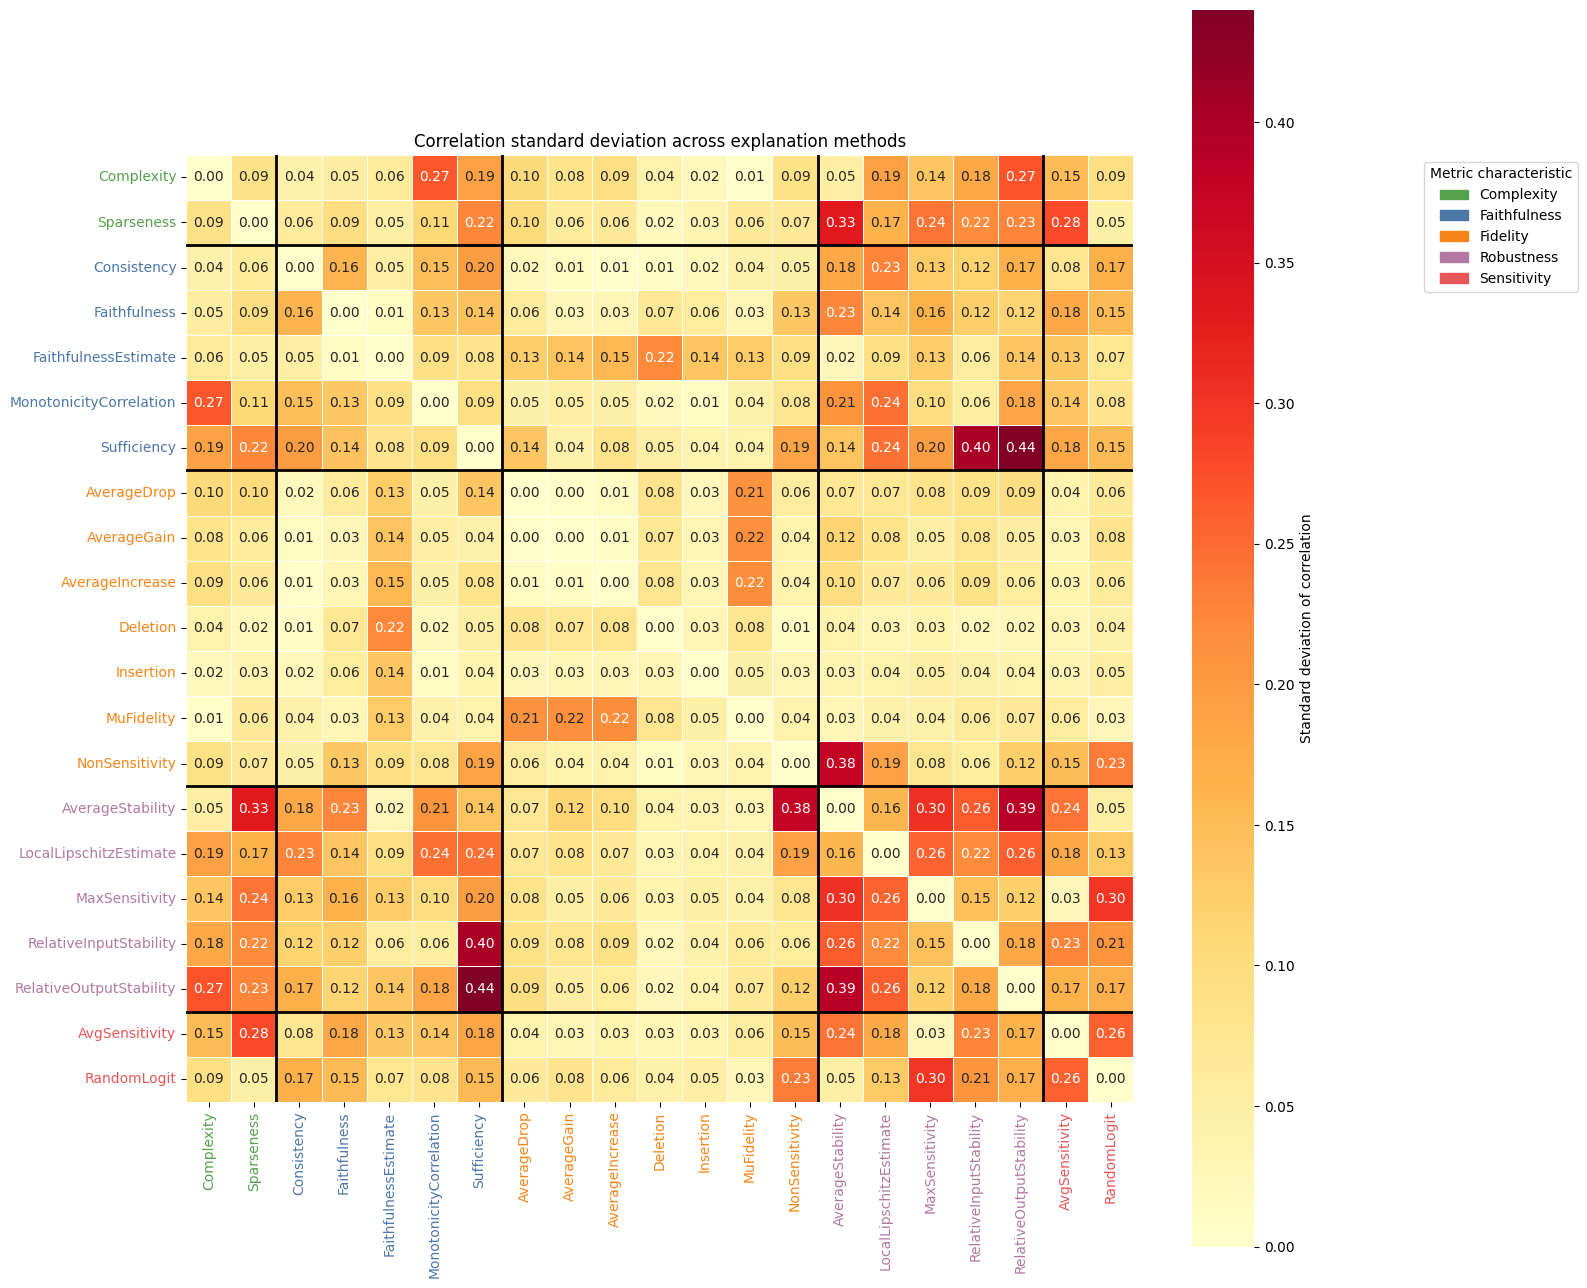

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,0.000000,0.004848,0.012771,0.073758,0.036569,0.104959,0.021224,0.079854,0.061426,0.126084,...,0.071004,0.081759,0.045723,0.209765,0.056777,0.062692,0.086707,0.094838,0.101771,0.136360
AverageGain,0.004848,0.000000,0.008187,0.116602,0.027688,0.082304,0.013613,0.071348,0.025346,0.140512,...,0.082102,0.050585,0.052743,0.215184,0.039143,0.079190,0.077227,0.054185,0.060161,0.041686
AverageIncrease,0.012771,0.008187,0.000000,0.097618,0.034744,0.091350,0.005900,0.077666,0.027908,0.154980,...,0.065035,0.062538,0.047822,0.218786,0.040328,0.060156,0.086609,0.058989,0.062967,0.080981
AverageStability,0.073758,0.116602,0.097618,0.000000,0.242033,0.052615,0.180151,0.038415,0.225010,0.024375,...,0.159557,0.304322,0.209321,0.030338,0.375705,0.048548,0.263424,0.388241,0.333031,0.139620
AvgSensitivity,0.036569,0.027688,0.034744,0.242033,0.000000,0.151498,0.079009,0.029367,0.179706,0.133052,...,0.177695,0.025331,0.137753,0.057200,0.150077,0.259358,0.225409,0.165126,0.280004,0.183862
Complexity,0.104959,0.082304,0.091350,0.052615,0.151498,0.000000,0.041530,0.040373,0.054927,0.060838,...,0.192102,0.137502,0.267788,0.006454,0.086464,0.092288,0.178762,0.269930,0.085135,0.187298
Consistency,0.021224,0.013613,0.005900,0.180151,0.079009,0.041530,0.000000,0.007872,0.161052,0.052935,...,0.228052,0.129645,0.148455,0.042413,0.045562,0.167673,0.118474,0.166815,0.061828,0.195973
Deletion,0.079854,0.071348,0.077666,0.038415,0.029367,0.040373,0.007872,0.000000,0.069109,0.223339,...,0.028646,0.034529,0.019999,0.077434,0.011983,0.043637,0.022657,0.024964,0.018150,0.051277
Faithfulness,0.061426,0.025346,0.027908,0.225010,0.179706,0.054927,0.161052,0.069109,0.000000,0.011866,...,0.140486,0.164975,0.133947,0.029024,0.133238,0.153211,0.122004,0.116711,0.094956,0.142532


In [102]:
stacked_correlations = pd.concat(
    {
        method: results['correlation']
        for method, results in method_correlations.items()
    },
    names=['method', 'metric']
)

mean_correlation_matrix = (stacked_correlations.groupby(level='metric').mean())
std_correlation_matrix = (stacked_correlations.groupby(level='metric').std())

plot_grouped_correlation_heatmap(
    correlation_matrix=mean_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Mean correlation across explanation methods",
)

display(mean_correlation_matrix)

plot_grouped_std_heatmap(
    std_matrix=std_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Correlation standard deviation across explanation methods",
)

display(std_correlation_matrix)

## Correlations by dataset

In [103]:
dataset_correlations = {}
dataset_pair_tables = []

for dataset_name in sorted(metric_wide['dataset_name'].dropna().unique()):
    dataset_data = metric_wide[metric_wide['dataset_name'] == dataset_name]

    correlation_matrix, sample_size_matrix = compute_correlation_matrix(
        dataset_data,
        metric_columns,
        method=CORRELATION_METHOD,
        min_pairs=MIN_PAIRS
    )

    dataset_correlations[dataset_name] = {
        "correlation": correlation_matrix,
        "n_pairs": sample_size_matrix
    }

    # Get and format the 20 highest correlations
    pairs = correlation_pairs(
        correlation_matrix,
        sample_size_matrix,
        top_n=20
    )

    pairs['dataset_name'] = dataset_name
    dataset_pair_tables.append(pairs)

all_dataset_pairs = []

for dataset, results in dataset_correlations.items():
    correlation_matrix = results['correlation'].rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    sample_size_matrix = results['n_pairs'].rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    upper_triangle = np.triu(
        np.ones(correlation_matrix.shape, dtype=bool),
        k=1
    )

    dataset_pairs = (
        correlation_matrix
        .where(upper_triangle)
        .stack()
        .rename('correlation')
        .reset_index()
    )

    dataset_pairs['n_pairs'] = dataset_pairs.apply(
        lambda row: sample_size_matrix.loc[
            row['metric_1'],
            row['metric_2']
        ],
        axis=1
    )

    dataset_pairs['dataset_name'] = dataset
    dataset_pairs['abs_correlation'] = dataset_pairs['correlation'].abs()

    all_dataset_pairs.append(dataset_pairs)

all_dataset_pairs = pd.concat(all_dataset_pairs, ignore_index=True)

correlation_summary = (
    all_dataset_pairs
    .groupby(['metric_1', 'metric_2'], as_index=False)
    .agg(
        # datasets_present=('dataset_name', 'nunique'),
        mean_correlation=('correlation', 'mean'),
        std_correlation=('correlation', 'std'),
        min_correlation=('correlation', 'min'),
        max_correlation=('correlation', 'max'),
        mean_abs_correlation=('abs_correlation', 'mean'),
        std_abs_correlation=('abs_correlation', 'std'),
        mean_n_pairs=('n_pairs', 'mean'),
    )
)

correlation_summary = correlation_summary.sort_values(
    ['mean_abs_correlation', 'std_correlation'],
    ascending=[False, True]
)

display(correlation_summary.head(30))

,metric_1,metric_2,mean_correlation,std_correlation,min_correlation,max_correlation,mean_abs_correlation,std_abs_correlation,mean_n_pairs
124,Complexity,Sparseness,-0.994916,0.000833,-0.995583,-0.993982,0.994916,0.000833,1456.000000
23,AverageGain,AverageIncrease,0.948872,0.026556,0.929758,0.979194,0.948872,0.026556,1456.000000
96,AvgSensitivity,MaxSensitivity,0.895607,0.045966,0.843403,0.930013,0.895607,0.045966,1456.000000
2,AverageDrop,AverageIncrease,-0.874647,0.062941,-0.921722,-0.803156,0.874647,0.062941,1456.000000
1,AverageDrop,AverageGain,-0.828815,0.037350,-0.856978,-0.786446,0.828815,0.037350,1456.000000
157,Deletion,Insertion,0.819576,0.027198,0.789023,0.841149,0.819576,0.027198,1456.000000
375,RelativeInputStability,RelativeOutputStability,0.590403,0.111987,0.463755,0.676336,0.590403,0.111987,752.333333
100,AvgSensitivity,RandomLogit,-0.564265,0.021404,-0.586036,-0.543249,0.564265,0.021404,1456.000000
10,AverageDrop,Insertion,-0.540224,0.162762,-0.660346,-0.354985,0.540224,0.162762,1456.000000
268,MaxSensitivity,RandomLogit,-0.528302,0.028742,-0.561057,-0.507292,0.528302,0.028742,1456.000000


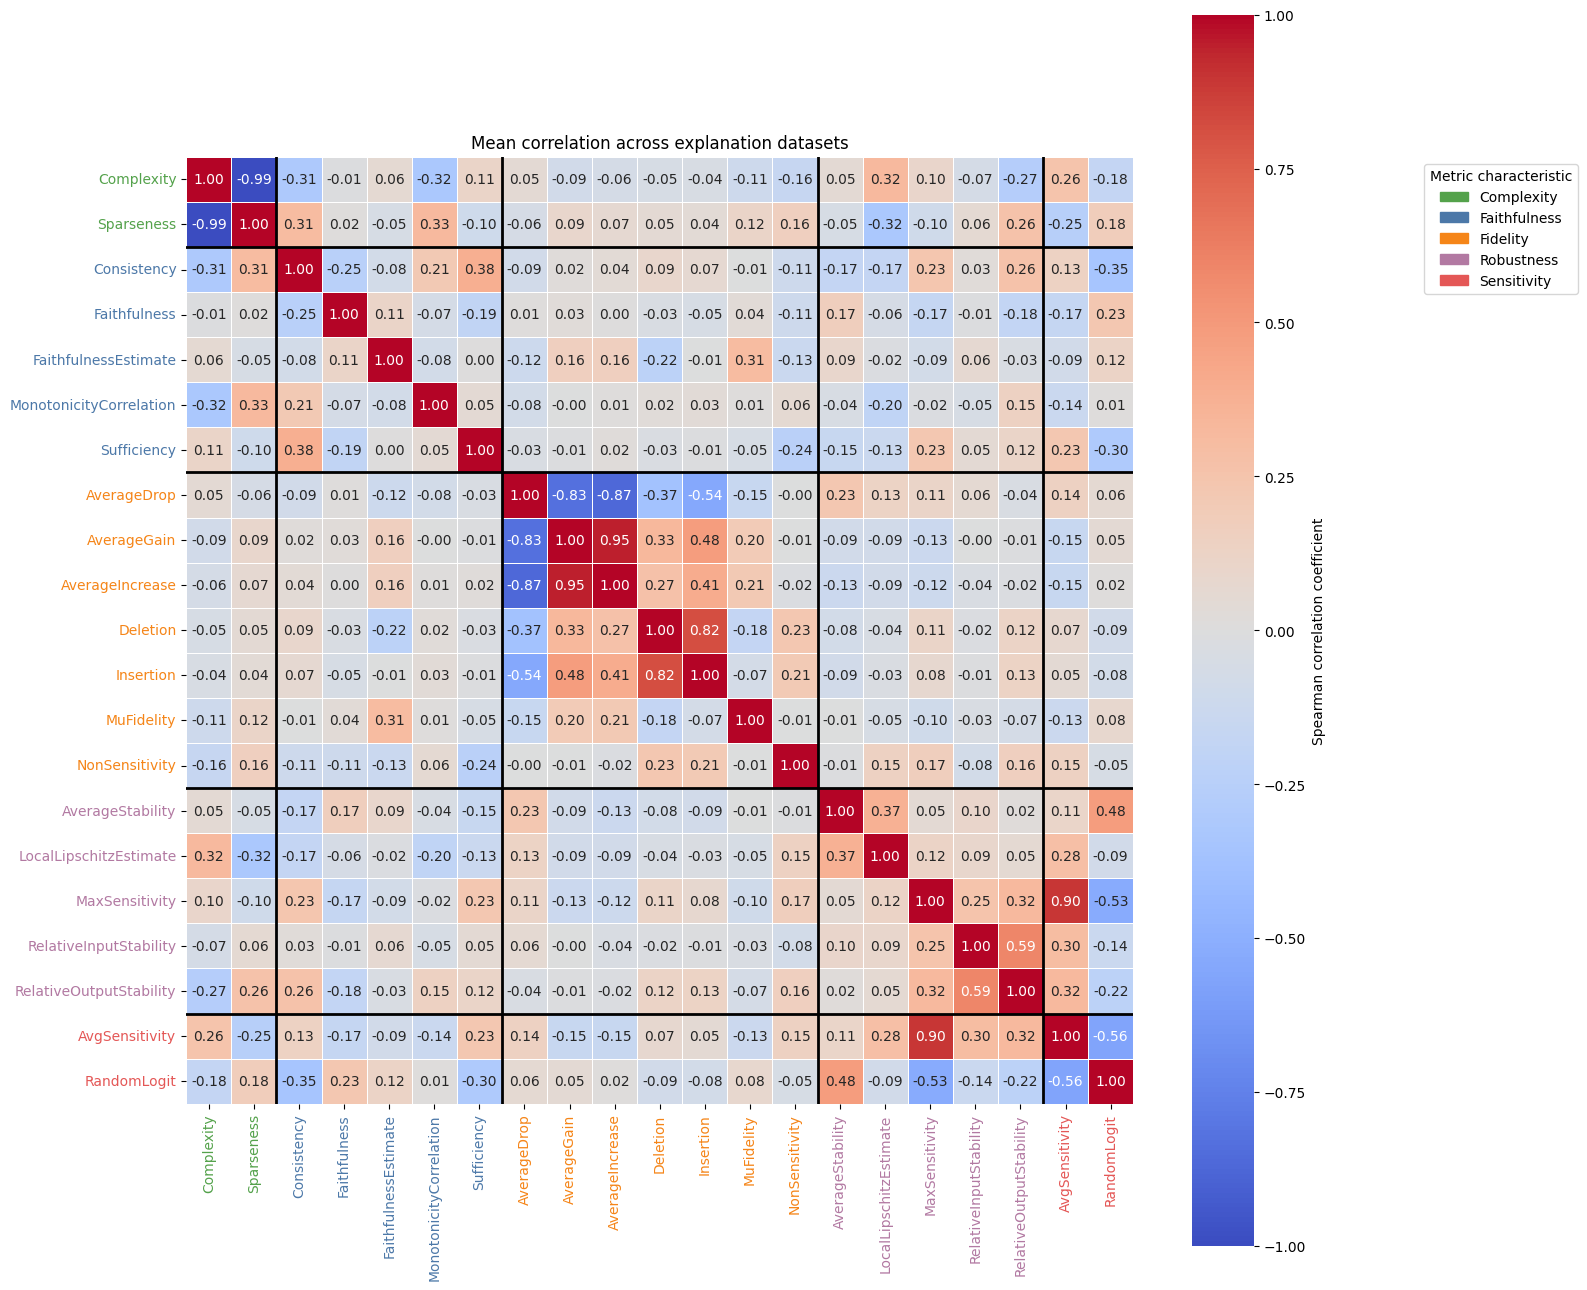

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,1.000000,-0.828815,-0.874647,0.227090,0.140676,0.052449,-0.092859,-0.374576,0.011183,-0.123290,...,0.127504,0.114384,-0.081440,-0.153419,-0.000579,0.058398,0.055743,-0.037254,-0.055194,-0.031320
AverageGain,-0.828815,1.000000,0.948872,-0.088639,-0.152620,-0.088616,0.018674,0.333286,0.030450,0.156790,...,-0.087100,-0.127699,-0.004070,0.197396,-0.007034,0.052491,-0.003530,-0.008638,0.092418,-0.013349
AverageIncrease,-0.874647,0.948872,1.000000,-0.129557,-0.150526,-0.064068,0.042766,0.266210,0.000815,0.161199,...,-0.091596,-0.122213,0.011091,0.212946,-0.015997,0.015155,-0.037845,-0.022007,0.068384,0.017618
AverageStability,0.227090,-0.088639,-0.129557,1.000000,0.107212,0.047755,-0.173637,-0.081399,0.165858,0.088031,...,0.368900,0.049868,-0.041997,-0.005048,-0.012105,0.478792,0.095026,0.017007,-0.052300,-0.153718
AvgSensitivity,0.140676,-0.152620,-0.150526,0.107212,1.000000,0.255708,0.134586,0.073405,-0.169872,-0.086895,...,0.284208,0.895607,-0.139377,-0.129193,0.145422,-0.564265,0.299094,0.322712,-0.253881,0.226670
Complexity,0.052449,-0.088616,-0.064068,0.047755,0.255708,1.000000,-0.310877,-0.053678,-0.014498,0.055959,...,0.322839,0.096068,-0.323891,-0.111721,-0.164006,-0.179060,-0.068371,-0.272742,-0.994916,0.111564
Consistency,-0.092859,0.018674,0.042766,-0.173637,0.134586,-0.310877,1.000000,0.090842,-0.246370,-0.084998,...,-0.174565,0.234693,0.211217,-0.006917,-0.109662,-0.345199,0.029318,0.260610,0.312148,0.384494
Deletion,-0.374576,0.333286,0.266210,-0.081399,0.073405,-0.053678,0.090842,1.000000,-0.034398,-0.218910,...,-0.039888,0.109962,0.023693,-0.177918,0.228808,-0.087990,-0.018957,0.121892,0.054201,-0.025357
Faithfulness,0.011183,0.030450,0.000815,0.165858,-0.169872,-0.014498,-0.246370,-0.034398,1.000000,0.113835,...,-0.058377,-0.169050,-0.070034,0.036592,-0.112954,0.228276,-0.011828,-0.181522,0.015093,-0.188668


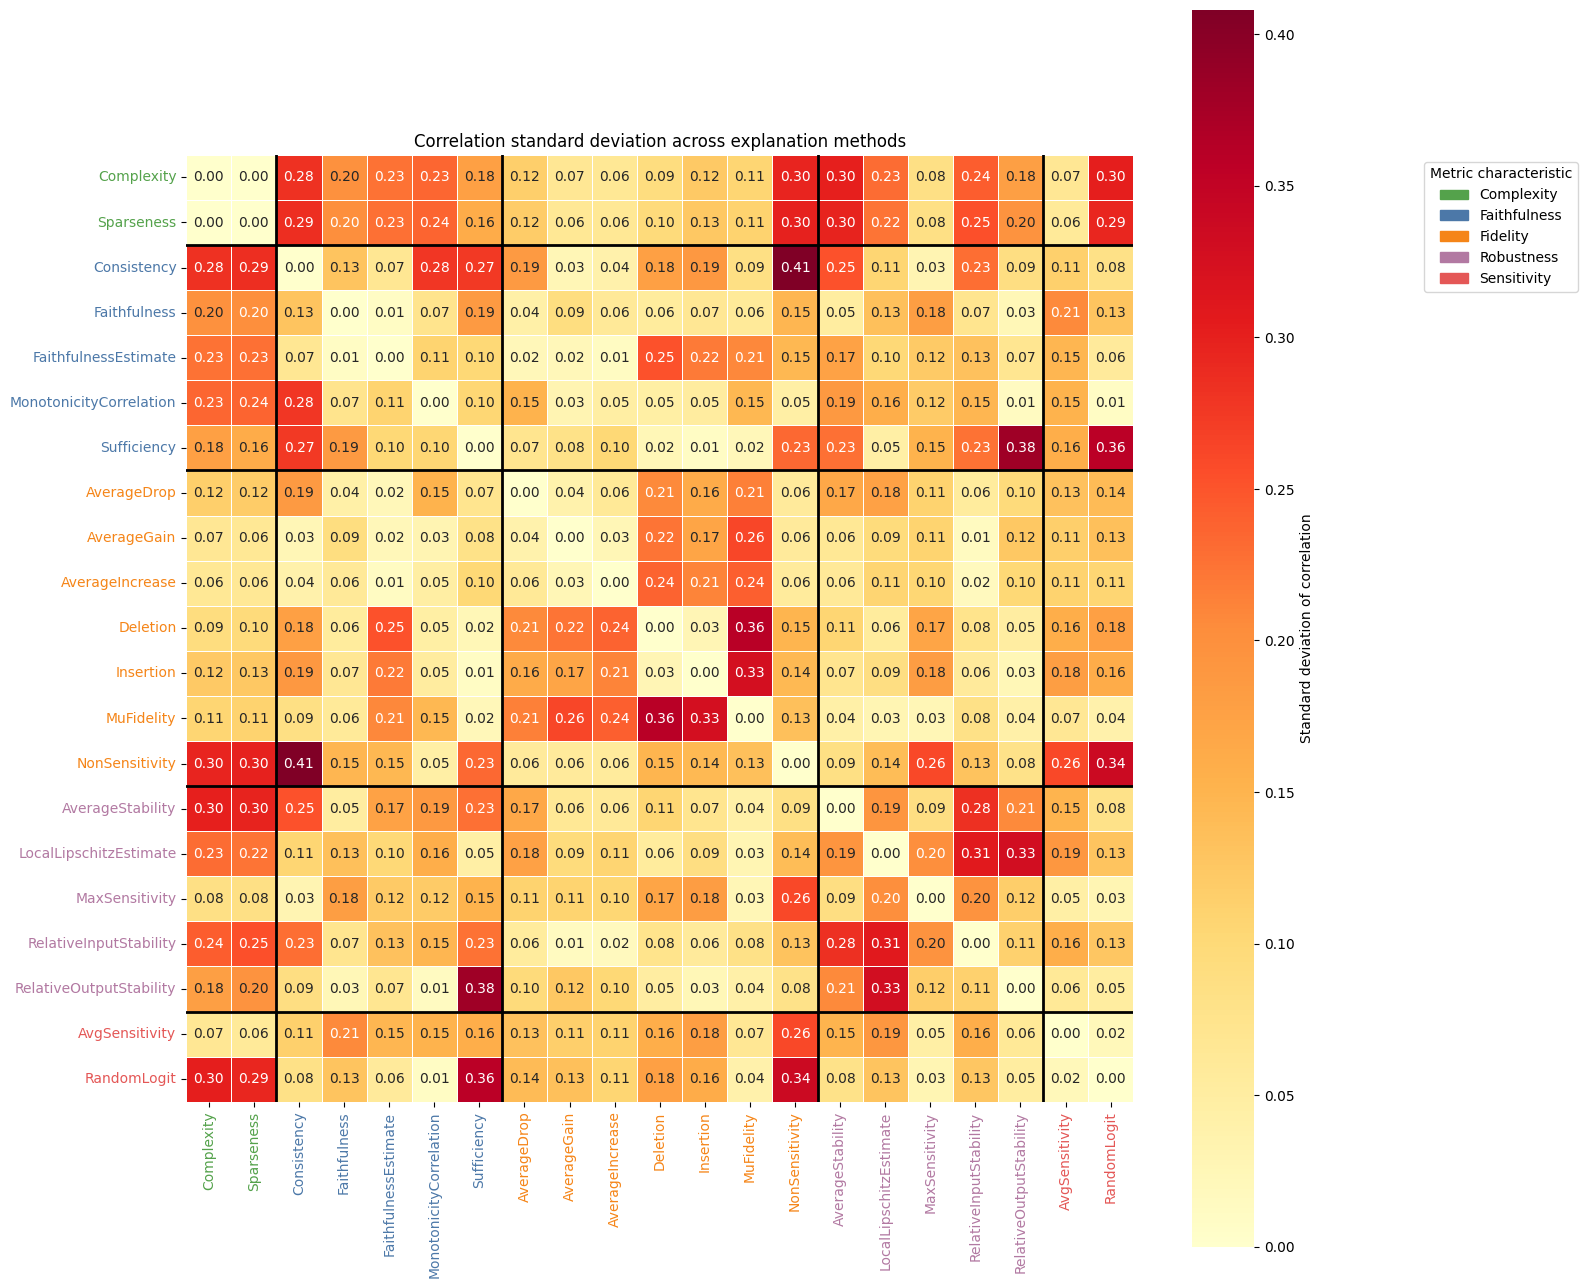

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,0.000000,0.037350,0.062941,0.167025,0.132419,0.115150,0.185783,0.207165,0.043465,0.023199,...,0.176879,0.110068,0.152274,0.214438,0.058587,0.140731,0.055625,0.096924,0.118667,0.072870
AverageGain,0.037350,0.000000,0.026556,0.064824,0.114991,0.066388,0.026041,0.224547,0.089963,0.023566,...,0.094525,0.109226,0.031709,0.261800,0.058871,0.134609,0.014849,0.124990,0.063824,0.080178
AverageIncrease,0.062941,0.026556,0.000000,0.060942,0.111503,0.063995,0.038936,0.239067,0.060845,0.011913,...,0.107940,0.103845,0.048402,0.241505,0.057323,0.105695,0.016882,0.102020,0.064636,0.103403
AverageStability,0.167025,0.064824,0.060942,0.000000,0.151072,0.301011,0.252629,0.106330,0.051359,0.173882,...,0.192885,0.088497,0.187621,0.043613,0.085583,0.079482,0.284347,0.206454,0.297400,0.227143
AvgSensitivity,0.132419,0.114991,0.111503,0.151072,0.000000,0.066688,0.113868,0.158466,0.205762,0.147824,...,0.189999,0.045966,0.152895,0.065960,0.260434,0.021404,0.158140,0.063342,0.059121,0.158791
Complexity,0.115150,0.066388,0.063995,0.301011,0.066688,0.000000,0.283060,0.091295,0.198287,0.225658,...,0.230637,0.083587,0.234850,0.106231,0.296320,0.302532,0.242517,0.179712,0.000833,0.178152
Consistency,0.185783,0.026041,0.038936,0.252629,0.113868,0.283060,0.000000,0.178489,0.129671,0.067886,...,0.106000,0.031086,0.277398,0.085182,0.408038,0.082616,0.229350,0.088409,0.285525,0.274212
Deletion,0.207165,0.224547,0.239067,0.106330,0.158466,0.091295,0.178489,0.000000,0.055094,0.251899,...,0.055770,0.171057,0.046818,0.359530,0.149102,0.178202,0.075155,0.050636,0.096087,0.024817
Faithfulness,0.043465,0.089963,0.060845,0.051359,0.205762,0.198287,0.129671,0.055094,0.000000,0.009590,...,0.134221,0.181444,0.074216,0.059792,0.148016,0.129544,0.072123,0.025003,0.200839,0.186060


In [104]:
stacked_correlations = pd.concat(
    {
        dataset_name: results['correlation']
        for dataset_name, results in dataset_correlations.items()
    },
    names=['dataset_name', 'metric']
)

mean_correlation_matrix = (stacked_correlations.groupby(level='metric').mean())
std_correlation_matrix = (stacked_correlations.groupby(level='metric').std())

plot_grouped_correlation_heatmap(
    correlation_matrix=mean_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Mean correlation across explanation datasets",
)

display(mean_correlation_matrix)

plot_grouped_std_heatmap(
    std_matrix=std_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Correlation standard deviation across explanation methods",
)

display(std_correlation_matrix)

## Correlations by model

In [105]:
model_correlations = {}
model_pair_tables = []

for model_name in sorted(metric_wide['model_name'].dropna().unique()):
    model_data = metric_wide[metric_wide['model_name'] == model_name]

    correlation_matrix, sample_size_matrix = compute_correlation_matrix(
        model_data,
        metric_columns,
        method=CORRELATION_METHOD,
        min_pairs=MIN_PAIRS
    )

    model_correlations[model_name] = {
        "correlation": correlation_matrix,
        "n_pairs": sample_size_matrix
    }

    # Get and format the 20 highest correlations
    pairs = correlation_pairs(
        correlation_matrix,
        sample_size_matrix,
        top_n=20
    )

    pairs['model_name'] = model_name
    model_pair_tables.append(pairs)

all_model_pairs = []

for model, results in model_correlations.items():
    correlation_matrix = results['correlation'].rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    sample_size_matrix = results['n_pairs'].rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    upper_triangle = np.triu(
        np.ones(correlation_matrix.shape, dtype=bool),
        k=1
    )

    model_pairs = (
        correlation_matrix
        .where(upper_triangle)
        .stack()
        .rename('correlation')
        .reset_index()
    )

    model_pairs['n_pairs'] = model_pairs.apply(
        lambda row: sample_size_matrix.loc[
            row['metric_1'],
            row['metric_2']
        ],
        axis=1
    )

    model_pairs['model_name'] = model
    model_pairs['abs_correlation'] = model_pairs['correlation'].abs()

    all_model_pairs.append(model_pairs)

all_model_pairs = pd.concat(all_model_pairs, ignore_index=True)

correlation_summary = (
    all_model_pairs
    .groupby(['metric_1', 'metric_2'], as_index=False)
    .agg(
        # models_present=('model_name', 'nunique'),
        mean_correlation=('correlation', 'mean'),
        std_correlation=('correlation', 'std'),
        min_correlation=('correlation', 'min'),
        max_correlation=('correlation', 'max'),
        mean_abs_correlation=('abs_correlation', 'mean'),
        std_abs_correlation=('abs_correlation', 'std'),
        mean_n_pairs=('n_pairs', 'mean'),
    )
)

correlation_summary = correlation_summary.sort_values(
    ['mean_abs_correlation', 'std_correlation'],
    ascending=[False, True]
)

display(correlation_summary.head(30))

,metric_1,metric_2,mean_correlation,std_correlation,min_correlation,max_correlation,mean_abs_correlation,std_abs_correlation,mean_n_pairs
23,AverageGain,AverageIncrease,0.947093,0.010476,0.933211,0.954814,0.947093,0.010476,728.000000
96,AvgSensitivity,MaxSensitivity,0.893995,0.074096,0.761206,0.954049,0.893995,0.074096,728.000000
2,AverageDrop,AverageIncrease,-0.891690,0.021333,-0.917889,-0.857705,0.891690,0.021333,728.000000
1,AverageDrop,AverageGain,-0.844354,0.013157,-0.856584,-0.818778,0.844354,0.013157,728.000000
157,Deletion,Insertion,0.799382,0.118241,0.654138,0.977252,0.799382,0.118241,728.000000
332,NonSensitivity,RelativeInputStability,-0.591378,0.070713,-0.686548,-0.491934,0.591378,0.070713,384.833333
100,AvgSensitivity,RandomLogit,-0.590268,0.078387,-0.724917,-0.508180,0.590268,0.078387,728.000000
10,AverageDrop,Insertion,-0.583472,0.215509,-0.834600,-0.323198,0.583472,0.215509,728.000000
122,Complexity,RelativeInputStability,-0.392759,0.479858,-0.716242,0.567027,0.581768,0.096075,384.833333
124,Complexity,Sparseness,-0.544720,0.188326,-0.913517,-0.378179,0.544720,0.188326,728.000000


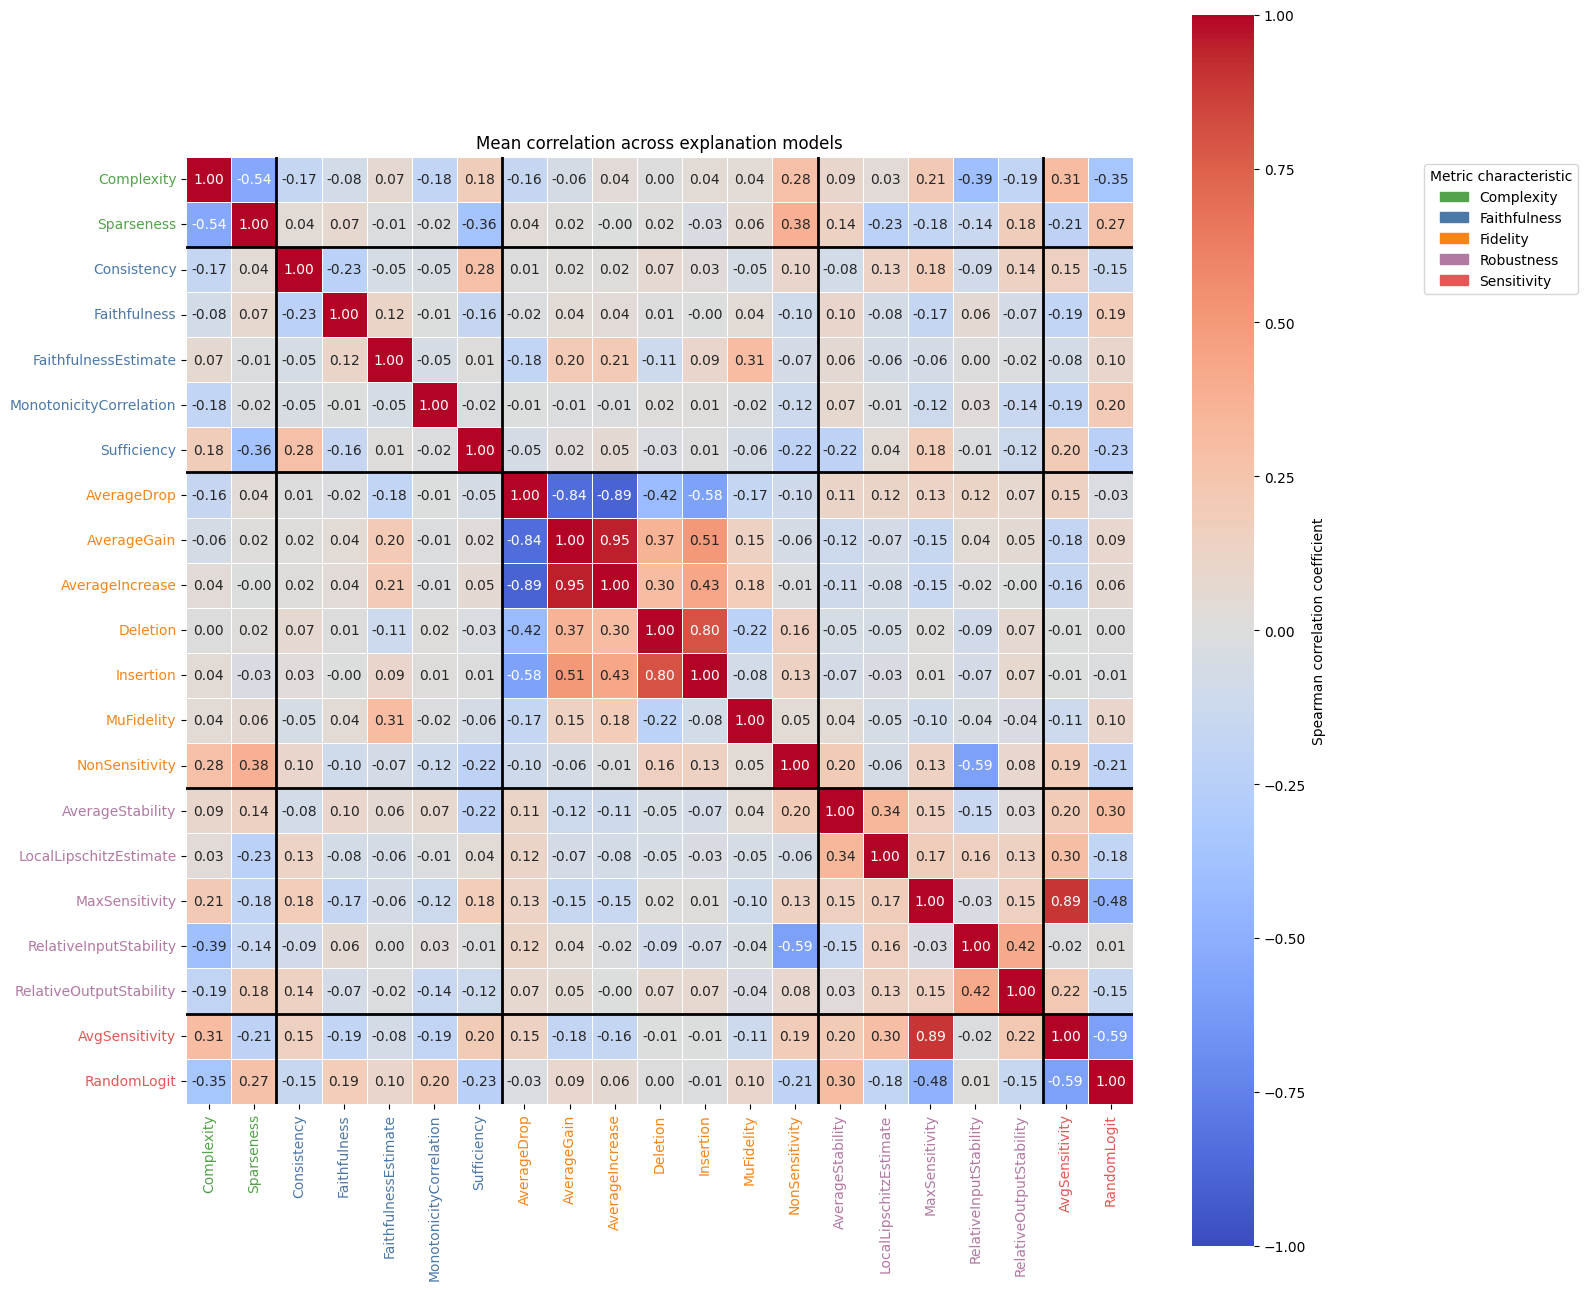

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,1.000000,-0.844354,-0.891690,0.112988,0.145747,-0.160029,0.005913,-0.424536,-0.021938,-0.181311,...,0.115274,0.131295,-0.005275,-0.166110,-0.104887,-0.029226,0.122219,0.072220,0.038728,-0.054887
AverageGain,-0.844354,1.000000,0.947093,-0.121357,-0.175100,-0.055962,0.018198,0.366339,0.043405,0.203549,...,-0.066557,-0.153283,-0.012125,0.145772,-0.061109,0.085908,0.042252,0.048784,0.015044,0.024833
AverageIncrease,-0.891690,0.947093,1.000000,-0.106481,-0.164610,0.035509,0.016875,0.301025,0.035443,0.208986,...,-0.077322,-0.147473,-0.013523,0.180696,-0.013373,0.057222,-0.022080,-0.004127,-0.004398,0.054713
AverageStability,0.112988,-0.121357,-0.106481,1.000000,0.202059,0.093697,-0.083292,-0.054364,0.097650,0.057104,...,0.340061,0.153109,0.071494,0.044819,0.202206,0.303806,-0.147050,0.028171,0.136510,-0.215128
AvgSensitivity,0.145747,-0.175100,-0.164610,0.202059,1.000000,0.309941,0.152571,-0.007514,-0.185960,-0.075212,...,0.296801,0.893995,-0.194143,-0.109629,0.193114,-0.590268,-0.017507,0.222900,-0.214776,0.199139
Complexity,-0.160029,-0.055962,0.035509,0.093697,0.309941,1.000000,-0.169881,0.002506,-0.081710,0.067110,...,0.032447,0.214528,-0.180074,0.040375,0.276016,-0.351494,-0.392759,-0.193150,-0.544720,0.176856
Consistency,0.005913,0.018198,0.016875,-0.083292,0.152571,-0.169881,1.000000,0.069279,-0.230313,-0.051751,...,0.131829,0.180449,-0.046228,-0.048996,0.100801,-0.152161,-0.090275,0.140703,0.043349,0.281080
Deletion,-0.424536,0.366339,0.301025,-0.054364,-0.007514,0.002506,0.069279,1.000000,0.005361,-0.112044,...,-0.051028,0.019747,0.017523,-0.221584,0.156679,0.000910,-0.087844,0.069817,0.018020,-0.028426
Faithfulness,-0.021938,0.043405,0.035443,0.097650,-0.185960,-0.081710,-0.230313,0.005361,1.000000,0.116563,...,-0.075667,-0.171124,-0.005903,0.044363,-0.100663,0.186698,0.061470,-0.069363,0.074936,-0.162253


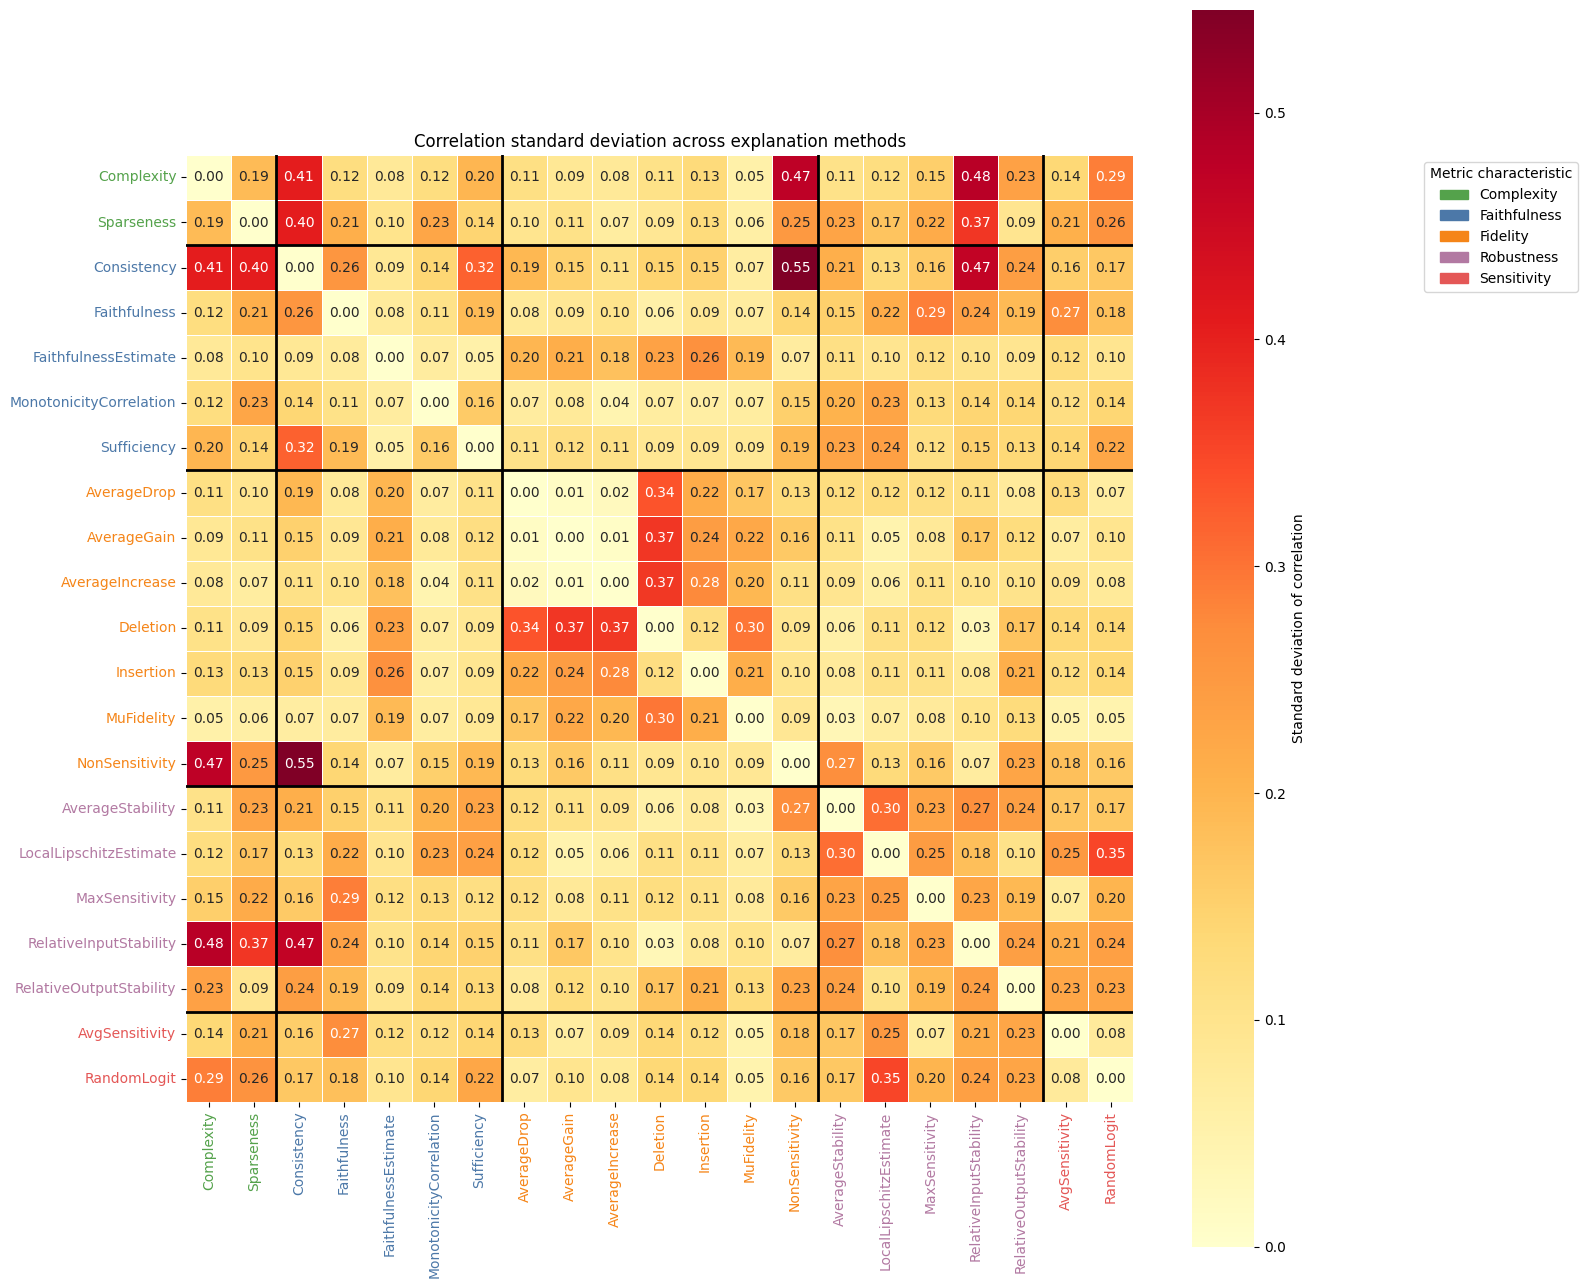

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,0.000000,0.013157,0.021333,0.122843,0.128777,0.114252,0.193921,0.336220,0.079626,0.197112,...,0.124022,0.116275,0.070709,0.168695,0.127390,0.066138,0.112579,0.077839,0.096181,0.106290
AverageGain,0.013157,0.000000,0.010476,0.107473,0.068188,0.085704,0.151091,0.371765,0.089065,0.211156,...,0.048610,0.082230,0.080548,0.223107,0.164085,0.097460,0.168054,0.124248,0.106594,0.117334
AverageIncrease,0.021333,0.010476,0.000000,0.093955,0.094175,0.082323,0.110341,0.370246,0.100233,0.178237,...,0.062768,0.106541,0.042791,0.195620,0.111594,0.079514,0.100391,0.103296,0.069679,0.110379
AverageStability,0.122843,0.107473,0.093955,0.000000,0.169949,0.105847,0.210663,0.058416,0.151796,0.112207,...,0.304620,0.231244,0.202551,0.034623,0.269592,0.166823,0.267533,0.240325,0.230409,0.231578
AvgSensitivity,0.128777,0.068188,0.094175,0.169949,0.000000,0.136784,0.157129,0.135894,0.272239,0.121795,...,0.250189,0.074096,0.118730,0.048499,0.179436,0.078387,0.214207,0.226933,0.208246,0.139100
Complexity,0.114252,0.085704,0.082323,0.105847,0.136784,0.000000,0.405523,0.108030,0.120230,0.082795,...,0.120864,0.154841,0.119705,0.054418,0.474220,0.287556,0.479858,0.234635,0.188326,0.197241
Consistency,0.193921,0.151091,0.110341,0.210663,0.157129,0.405523,0.000000,0.146240,0.256834,0.085411,...,0.127886,0.163803,0.139832,0.067690,0.545282,0.167010,0.467176,0.240757,0.404970,0.320972
Deletion,0.336220,0.371765,0.370246,0.058416,0.135894,0.108030,0.146240,0.000000,0.055800,0.232758,...,0.111687,0.121177,0.068763,0.296901,0.091645,0.137889,0.032651,0.172733,0.089042,0.089898
Faithfulness,0.079626,0.089065,0.100233,0.151796,0.272239,0.120230,0.256834,0.055800,0.000000,0.076306,...,0.216355,0.287737,0.107791,0.070340,0.138719,0.179711,0.235099,0.191651,0.210665,0.187975


In [106]:
stacked_correlations = pd.concat(
    {
        model_name: results['correlation']
        for model_name, results in model_correlations.items()
    },
    names=['model_name', 'metric']
)

mean_correlation_matrix = (stacked_correlations.groupby(level='metric').mean())
std_correlation_matrix = (stacked_correlations.groupby(level='metric').std())

plot_grouped_correlation_heatmap(
    correlation_matrix=mean_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Mean correlation across explanation models",
)

display(mean_correlation_matrix)

plot_grouped_std_heatmap(
    std_matrix=std_correlation_matrix,
    metric_characteristics=metric_characteristics,
    title="Correlation standard deviation across explanation methods",
)

display(std_correlation_matrix)

# Clustering

In [107]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

CLUSTER_MIN_PAIRS = 30

In [108]:
clustering_metrics = [
    metric
    for metric in metric_columns
    if metric in LOWER_IS_BETTER or metric in HIGHER_IS_BETTER
]

oriented_data = metric_wide[['method'] + clustering_metrics].copy()

for metric in LOWER_IS_BETTER:
    if metric in oriented_data.columns:
        oriented_data[metric] = -oriented_data[metric]

ranked_data = oriented_data.copy()

for metric in clustering_metrics:
    ranked_data[metric] = ranked_data.groupby('method')[metric].rank(pct=True)

global_metric_correlation = ranked_data[
    clustering_metrics
].corr(
    method='pearson',
    min_periods=CLUSTER_MIN_PAIRS
)

global_metric_correlation = global_metric_correlation.fillna(0.0)

metric_distance = 1 - global_metric_correlation

metric_distance = pd.DataFrame(
    np.where(
        np.eye(len(metric_distance), dtype=bool),
        0.0,
        metric_distance.to_numpy()
    ),
    index=metric_distance.index,
    columns=metric_distance.columns
)

display(global_metric_correlation)

metric,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,Consistency,Deletion,Faithfulness,FaithfulnessEstimate,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,1.000000,0.844186,0.891400,0.191459,0.163049,-0.079824,0.054474,-0.418457,0.001903,0.135830,...,0.181458,0.121131,0.066529,0.144471,-0.060819,0.008157,0.084396,0.052237,0.022448,0.087329
AverageGain,0.844186,1.000000,0.947034,0.112443,0.202039,0.064795,0.027229,-0.342611,0.052382,0.158971,...,0.109533,0.162123,0.012607,0.139393,0.056630,-0.102599,-0.019992,-0.008155,0.050229,0.030175
AverageIncrease,0.891400,0.947034,1.000000,0.127422,0.181810,-0.000210,0.049874,-0.253441,0.024985,0.167144,...,0.134684,0.142490,0.016109,0.164688,0.016313,-0.050514,0.049666,0.036237,0.040532,0.075100
AverageStability,0.191459,0.112443,0.127422,1.000000,0.276138,0.267665,0.285876,-0.097293,-0.094161,-0.059020,...,0.415555,0.098203,0.174137,0.010443,0.206839,0.317912,-0.123523,-0.109771,0.012553,0.192034
AvgSensitivity,0.163049,0.202039,0.181810,0.276138,1.000000,0.211664,-0.103837,0.044272,0.158090,0.091931,...,0.353203,0.906675,0.101672,0.110412,0.219935,-0.499322,0.085979,0.294901,0.154426,-0.116323
Complexity,-0.079824,0.064795,-0.000210,0.267665,0.211664,1.000000,0.329565,-0.020199,-0.016852,-0.079607,...,0.124650,0.056282,0.341356,-0.010143,0.225782,-0.126121,-0.270474,-0.389413,0.577657,0.021836
Consistency,0.054474,0.027229,0.049874,0.285876,-0.103837,0.329565,1.000000,-0.055038,-0.259748,-0.066472,...,0.205816,-0.236618,0.220226,-0.015923,0.056219,0.352179,0.074067,-0.328586,0.247402,0.467678
Deletion,-0.418457,-0.342611,-0.253441,-0.097293,0.044272,-0.020199,-0.055038,1.000000,0.010962,0.210297,...,-0.046629,0.074168,-0.038825,0.270343,0.156747,-0.048772,-0.036117,0.106110,-0.044736,0.027534
Faithfulness,0.001903,0.052382,0.024985,-0.094161,0.158090,-0.016852,-0.259748,0.010962,1.000000,0.104908,...,0.014553,0.178641,-0.065518,0.021571,0.063096,-0.120953,-0.054968,0.126063,-0.003961,-0.186262


## Dendogram

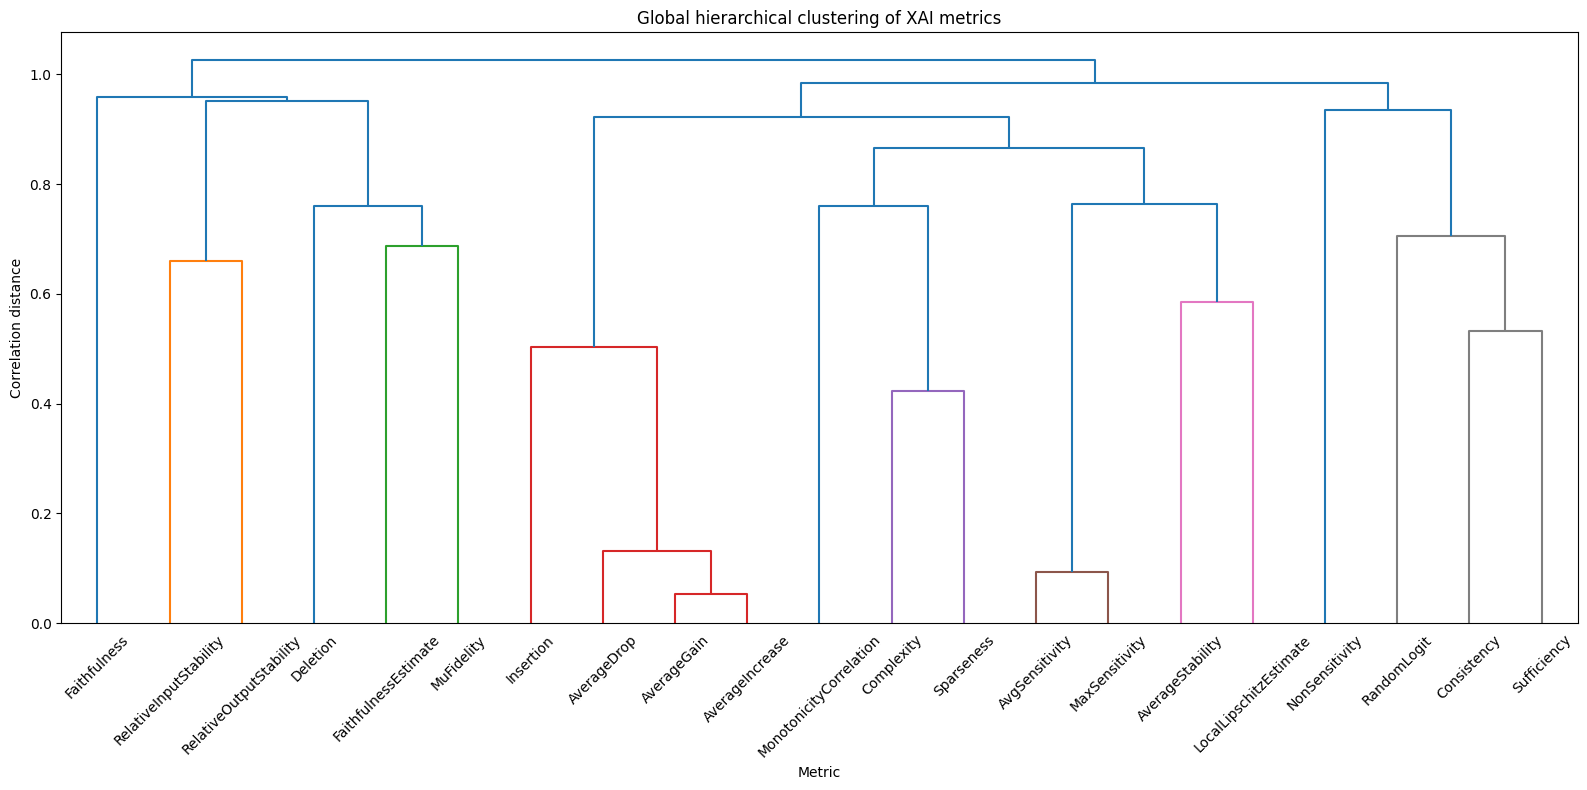

In [109]:
condensed_distance = squareform(metric_distance.to_numpy(), checks=False)

linkage_matrix = linkage(condensed_distance, method='average')

plt.figure(figsize=(16, 8))

dendrogram(
    linkage_matrix,
    labels=clustering_metrics,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title("Global hierarchical clustering of XAI metrics")
plt.xlabel("Metric")
plt.ylabel("Correlation distance")
plt.tight_layout()
plt.show()

## Choosing the number of clusters

,n_clusters,silhouette_score
0,2,0.138750
1,3,0.130190
2,4,0.115830
3,5,0.147616
4,6,0.130685
5,7,0.235464
6,8,0.273296


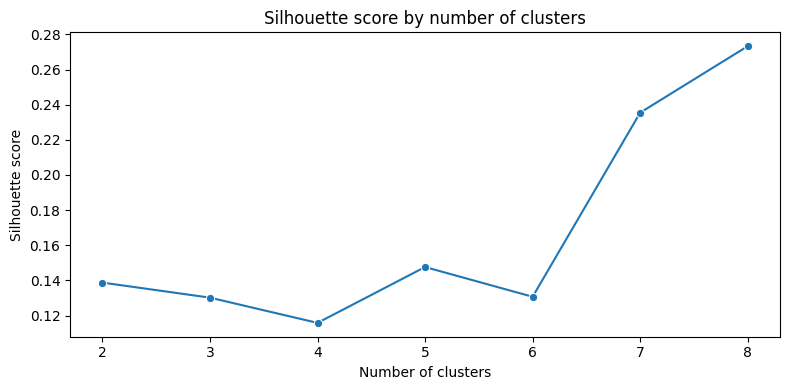

In [110]:
cluster_quality = []

max_clusters = min(8, len(clustering_metrics) - 1)

for n_clusters in range(2, max_clusters + 1):
    labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
    score = silhouette_score(metric_distance.to_numpy(), labels, metric='precomputed')
    
    cluster_quality.append(
        {
            "n_clusters": n_clusters,
            "silhouette_score": score
        }
    )

cluster_quality = pd.DataFrame(cluster_quality)

display(cluster_quality)

plt.figure(figsize=(8, 4))

sns.lineplot(
    data=cluster_quality,
    x="n_clusters",
    y="silhouette_score",
    marker="o",
)

plt.title("Silhouette score by number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.xticks(cluster_quality["n_clusters"])
plt.tight_layout()
plt.show()

## Assign metrics to global clusters

In [111]:
N_CLUSTERS = int(
    cluster_quality.loc[cluster_quality['silhouette_score'].idxmax(), 'n_clusters']
)

cluster_labels = fcluster(linkage_matrix, t=N_CLUSTERS, criterion='maxclust')

metric_clusters = pd.DataFrame(
    {
        "metric": clustering_metrics,
        "cluster": cluster_labels
    }
).sort_values(['cluster', 'metric'])

display(metric_clusters.sort_values(['cluster']))

for cluster_id, subset in metric_clusters.groupby("cluster"):
    print(f"\nCluster {cluster_id}")
    print(", ".join(subset['metric']))

,metric,cluster
17,RelativeInputStability,1
18,RelativeOutputStability,1
7,Deletion,2
9,FaithfulnessEstimate,2
14,MuFidelity,2
8,Faithfulness,3
0,AverageDrop,4
1,AverageGain,4
2,AverageIncrease,4
10,Insertion,4



Cluster 1
RelativeInputStability, RelativeOutputStability

Cluster 2
Deletion, FaithfulnessEstimate, MuFidelity

Cluster 3
Faithfulness

Cluster 4
AverageDrop, AverageGain, AverageIncrease, Insertion

Cluster 5
Complexity, MonotonicityCorrelation, Sparseness

Cluster 6
AverageStability, AvgSensitivity, LocalLipschitzEstimate, MaxSensitivity

Cluster 7
Consistency, RandomLogit, Sufficiency

Cluster 8
NonSensitivity


c:\Users\mtalba\Desktop\XAIMetrics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\mtalba\Desktop\XAIMetrics\.venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


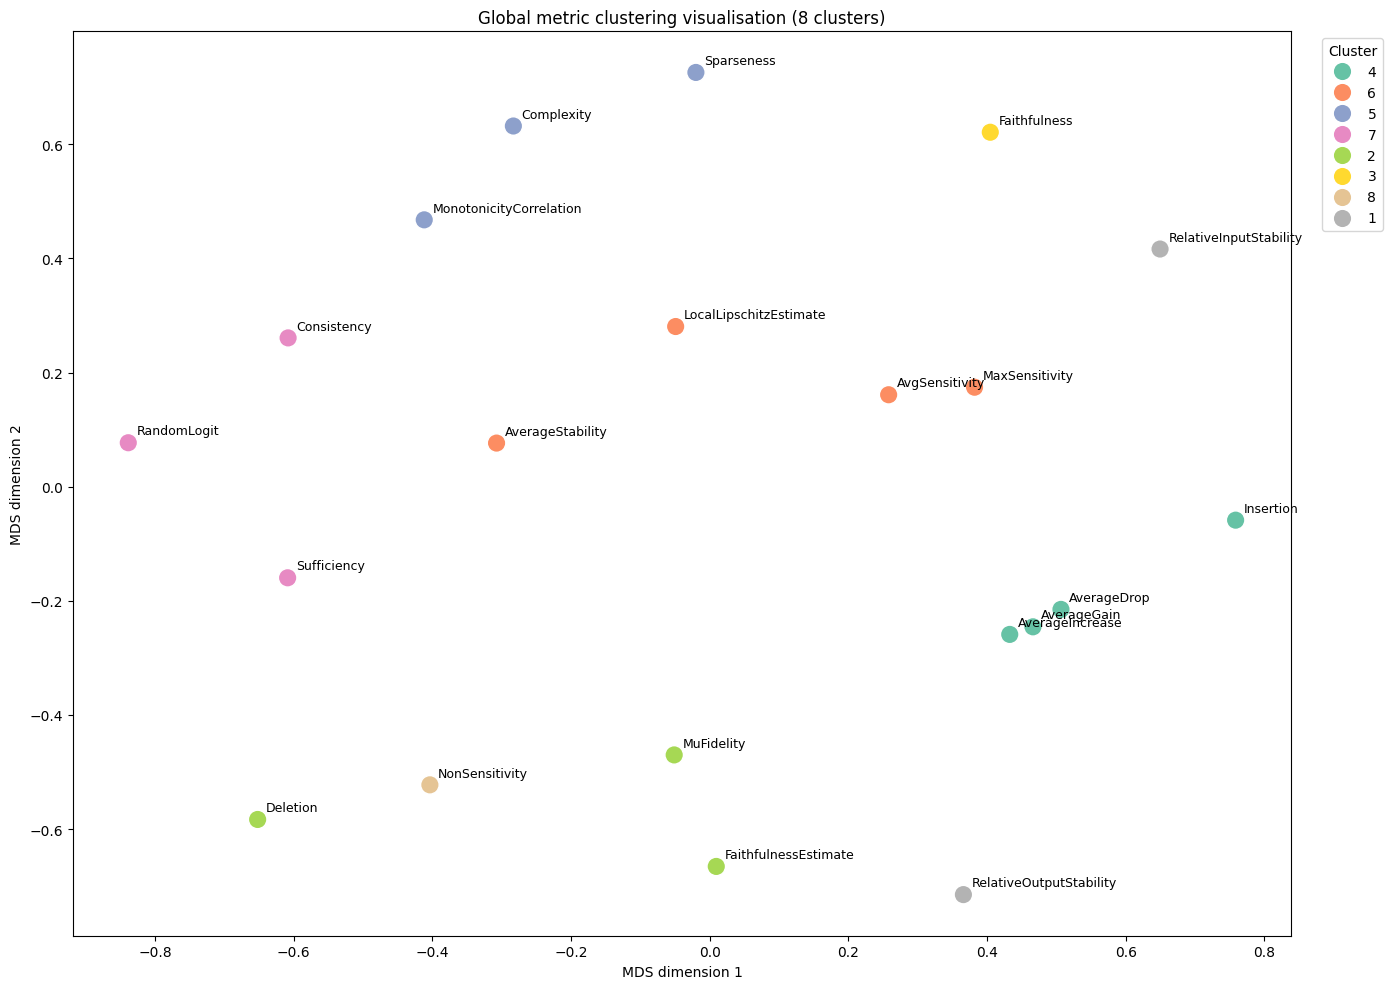

In [112]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=42,
)

metric_coordinates = mds.fit_transform(
    metric_distance.to_numpy()
)

cluster_plot = pd.DataFrame(
    {
        "metric": clustering_metrics,
        "cluster": cluster_labels.astype(str),
        "x": metric_coordinates[:, 0],
        "y": metric_coordinates[:, 1],
    }
)

plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=cluster_plot,
    x="x",
    y="y",
    hue="cluster",
    palette="Set2",
    s=180,
)

for row in cluster_plot.itertuples():
    plt.annotate(
        row.metric,
        (row.x, row.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

plt.title(
    f"Global metric clustering visualisation ({N_CLUSTERS} clusters)"
)
plt.xlabel("MDS dimension 1")
plt.ylabel("MDS dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Clustered correlation heatmap

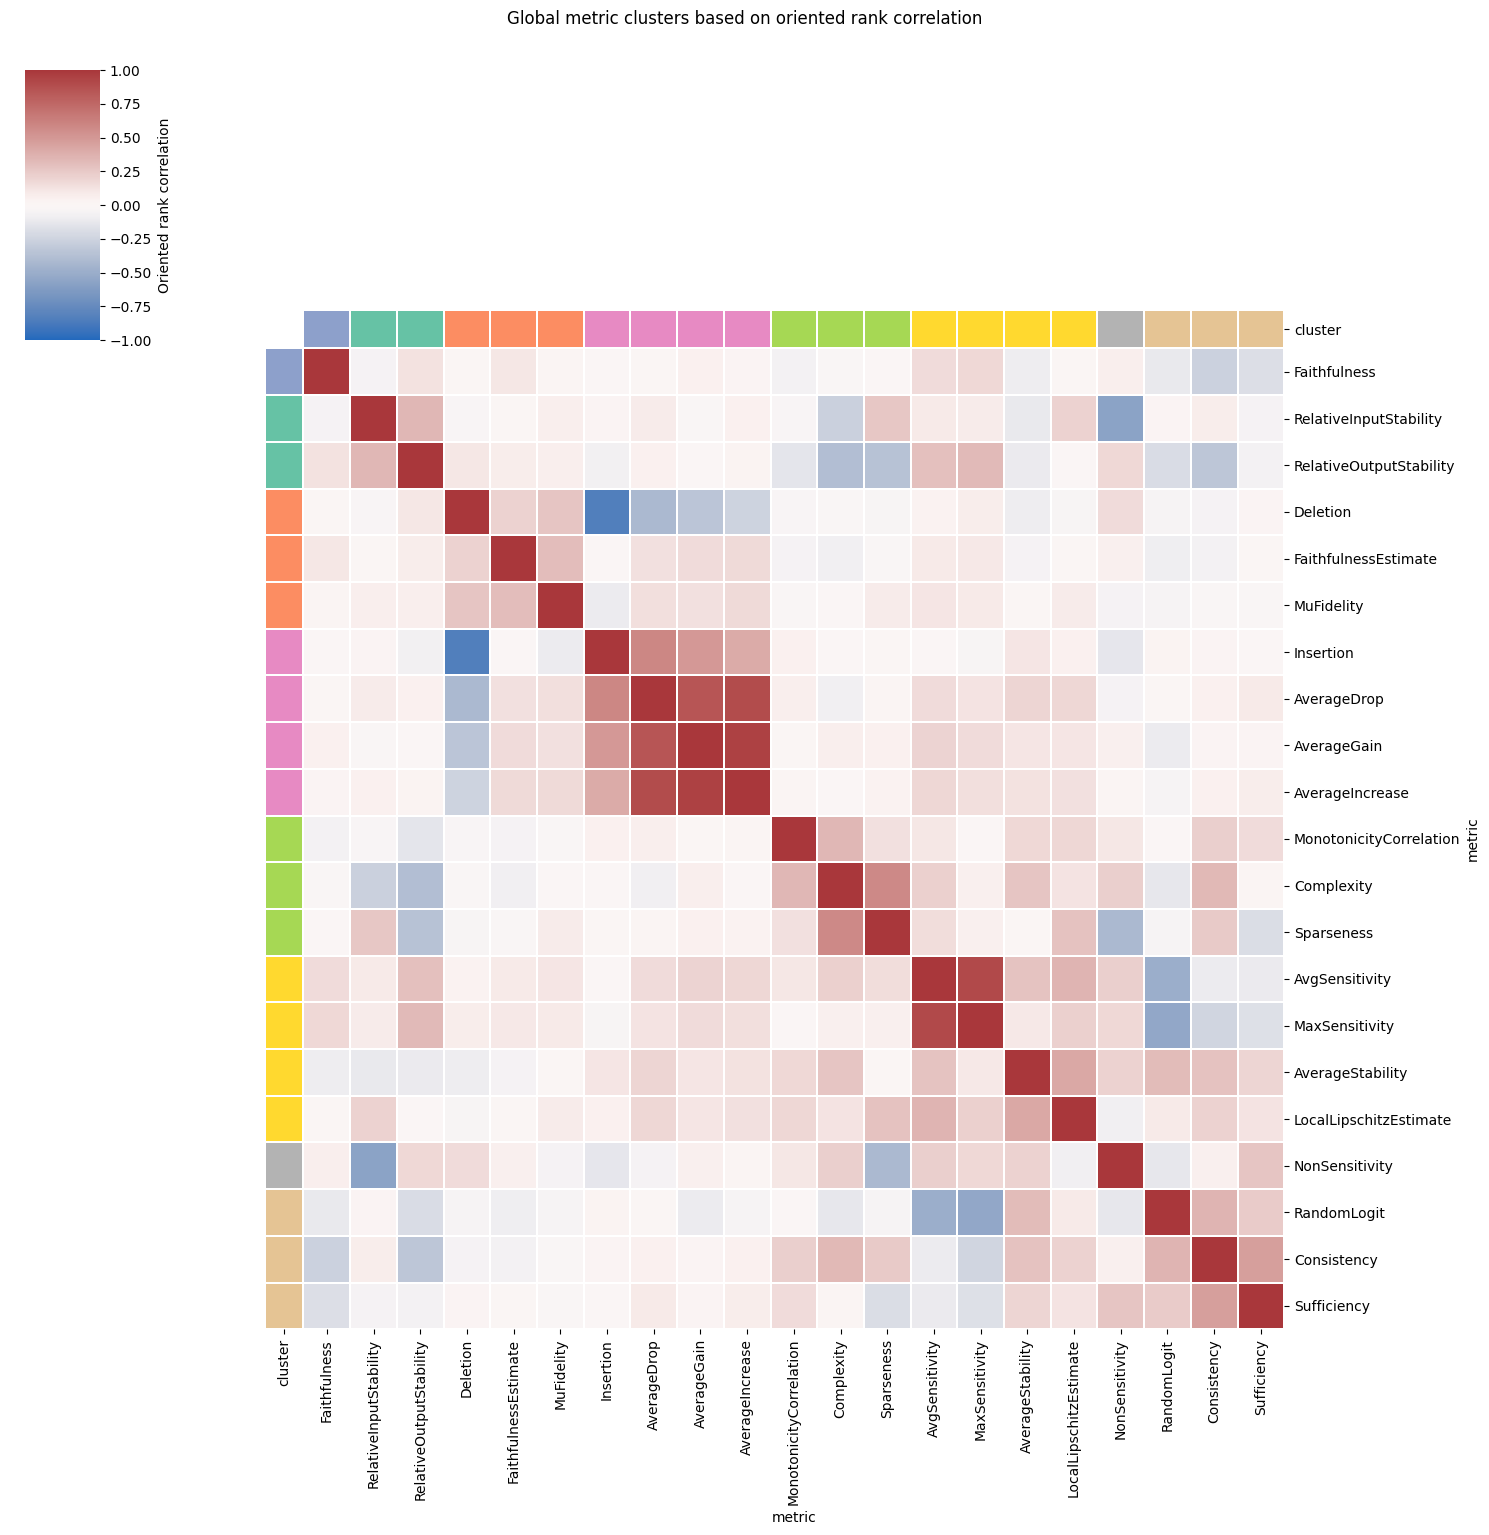

In [113]:
metric_order = dendrogram(linkage_matrix, labels=clustering_metrics, no_plot=True)["ivl"]

ordered_correlation = global_metric_correlation.loc[metric_order, metric_order]

cluster_palette = sns.color_palette("Set2", n_colors=N_CLUSTERS)

cluster_color_map = {
    cluster_id: cluster_palette[cluster_id - 1]
    for cluster_id in range(1, N_CLUSTERS + 1)
}

row_colors = (
    metric_clusters.set_index('metric')
    .loc[metric_order, 'cluster']
    .map(cluster_color_map)
)

sns.clustermap(
    ordered_correlation,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=row_colors,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.25,
    figsize=(15, 15),
    cbar_kws={"label": "Oriented rank correlation"},
)
plt.suptitle(
    "Global metric clusters based on oriented rank correlation",
    y=1.02,
)
plt.show()

# PCA (Principal Component Analysis)

In [114]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

PCA_RANK_WITHIN_METHOD = True

pca_features = clustering_metrics.copy()

pca_metadata = [
    "dataset_name",
    "model_name",
    "observation",
    "method"
]

In [115]:
pca_input = metric_wide[pca_metadata + pca_features].copy()

for metric in LOWER_IS_BETTER:
    if metric in pca_input.columns:
        pca_input[metric] = -pca_input[metric]

if PCA_RANK_WITHIN_METHOD:
    for metric in pca_features:
        pca_input[metric] = pca_input.groupby('method')[metric].rank(pct=True)

imputer = SimpleImputer(strategy='median')
pca_imputed = imputer.fit_transform(pca_input[pca_features])

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_imputed)

print(f"PCA observations: {pca_scaled.shape[0]:,}")
print(f"PCA metrics: {pca_scaled.shape[1]}")

PCA observations: 4,368
PCA metrics: 21


## Fit PCA and explained variance

In [121]:
pca = PCA()

pca_scores_array = pca.fit_transform(pca_scaled)

explained_variance = pd.DataFrame(
    {
        "component": [
            f"PC{i+1}"
            for i in range(len(pca.explained_variance_ratio_))
        ],
        "explained_variance_ration": pca.explained_variance_ratio_,
        "explained_variance_pct": (100 * pca.explained_variance_ratio_),
        "cumulative_variance_pct": (100 * np.cumsum(pca.explained_variance_ratio_))
    }
)

display(explained_variance)

,component,explained_variance_ration,explained_variance_pct,cumulative_variance_pct
0,PC1,0.175531,17.553084,17.553084
1,PC2,0.137401,13.740059,31.293144
2,PC3,0.118253,11.825277,43.118421
3,PC4,0.092152,9.215236,52.333657
4,PC5,0.080016,8.001562,60.335219
5,PC6,0.071596,7.159576,67.494794
6,PC7,0.050666,5.066564,72.561358
7,PC8,0.042720,4.271982,76.833341
8,PC9,0.038493,3.849312,80.682652
9,PC10,0.037127,3.712748,84.395400


## Scree plot

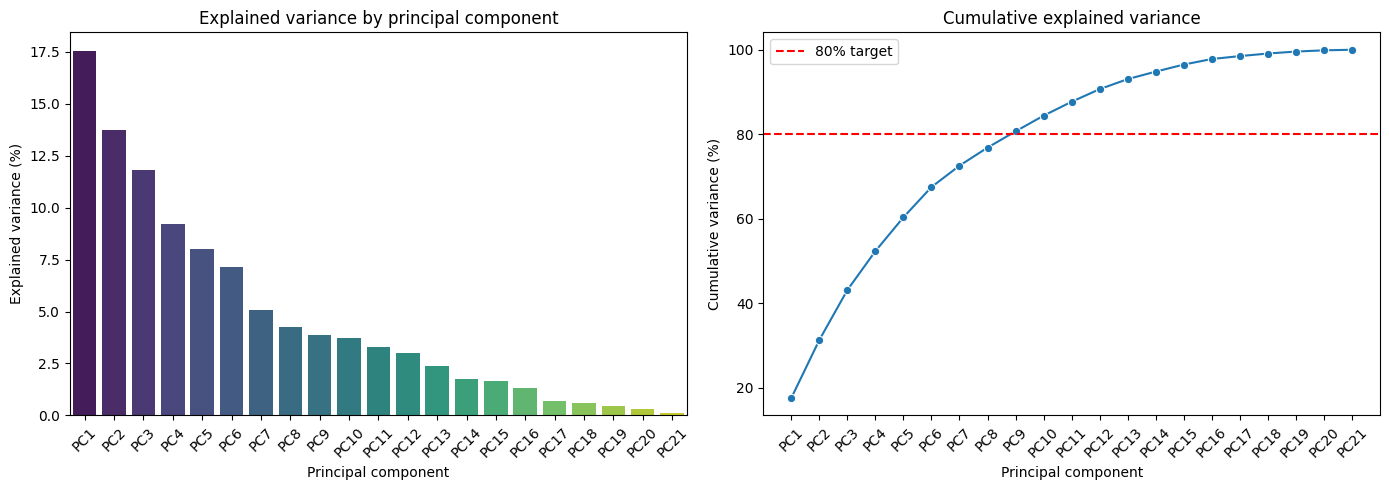

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=explained_variance,
    x="component",
    y="explained_variance_pct",
    hue="component",
    palette="viridis",
    legend=False,
    ax=axes[0],
)

axes[0].set_title("Explained variance by principal component")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=explained_variance,
    x="component",
    y="cumulative_variance_pct",
    marker="o",
    ax=axes[1],
)

axes[1].axhline(
    80,
    linestyle="--",
    color="red",
    label="80% target",
)

axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## PCA scores by dataset, model, and method

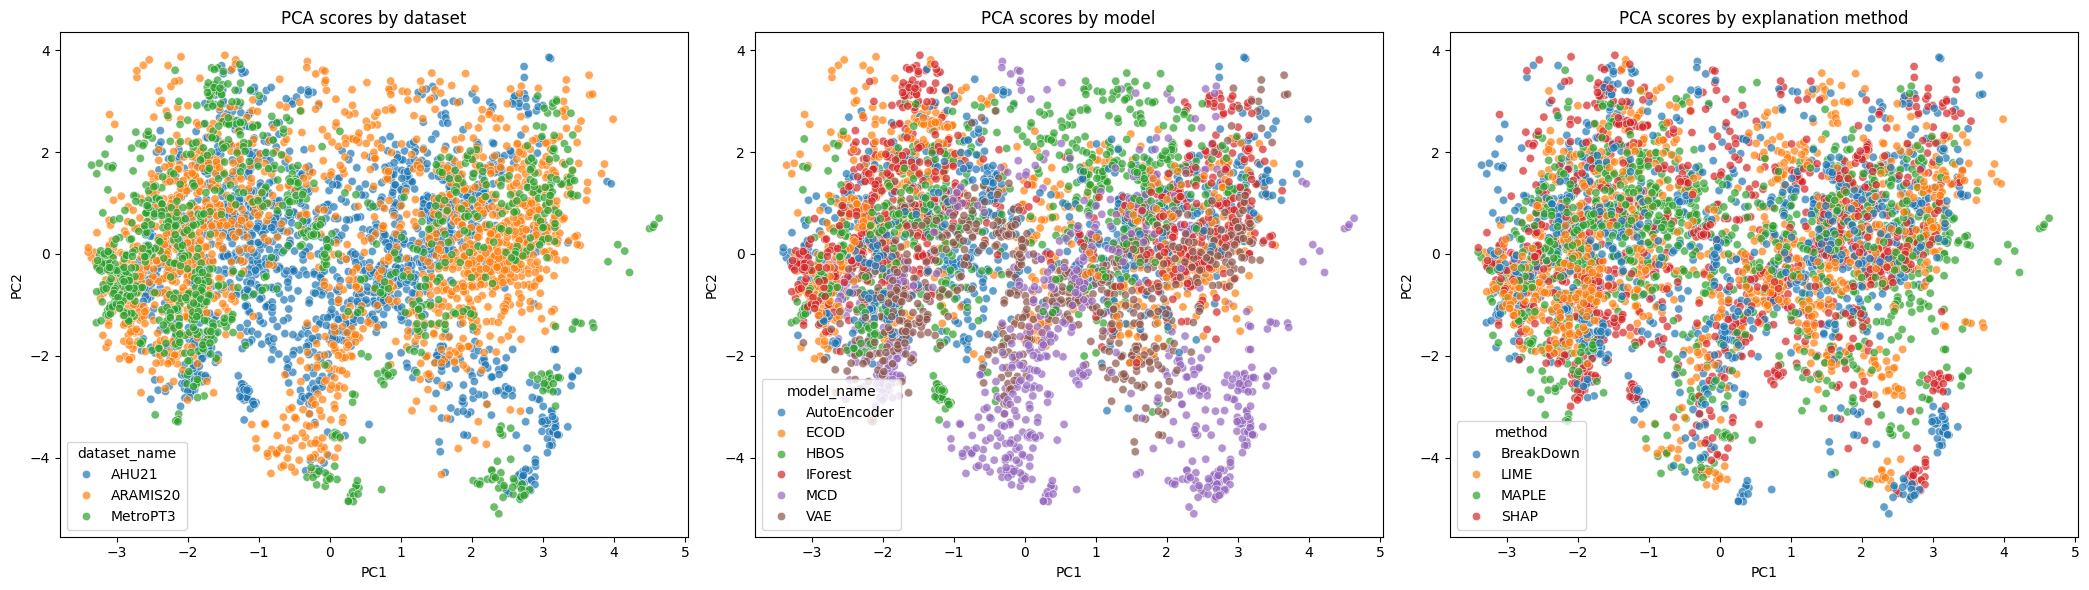

In [118]:
pca_scores = pca_input[pca_metadata].copy()

for component_index in range(pca_scores_array.shape[1]):
    pca_scores[f"PC{component_index + 1}"] = (
        pca_scores_array[:, component_index]
    )

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.scatterplot(
    data=pca_scores,
    x="PC1",
    y="PC2",
    hue="dataset_name",
    alpha=0.7,
    ax=axes[0],
)

axes[0].set_title("PCA scores by dataset")

sns.scatterplot(
    data=pca_scores,
    x="PC1",
    y="PC2",
    hue="model_name",
    alpha=0.7,
    ax=axes[1],
)

axes[1].set_title("PCA scores by model")

sns.scatterplot(
    data=pca_scores,
    x="PC1",
    y="PC2",
    hue="method",
    alpha=0.7,
    ax=axes[2],
)

axes[2].set_title("PCA scores by explanation method")

plt.tight_layout()
plt.show()

## Metric loadings

In [119]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[
        f"PC{i + 1}"
        for i in range(pca.components_.shape[0])
    ],
)

pca_loadings.index.name = "metric"

pca_loadings["PC1_abs_loading"] = (
    pca_loadings["PC1"].abs()
)

pca_loadings["PC2_abs_loading"] = (
    pca_loadings["PC2"].abs()
)

display(
    pca_loadings.sort_values(
        "PC1_abs_loading",
        ascending=False,
    )
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC1_abs_loading,PC2_abs_loading
metric,,,,,,,,,,,,,,,,,,,,,
AverageDrop,0.467027,-0.057125,-0.152667,0.067708,0.093971,-0.048966,-0.024583,-0.021289,-0.070568,0.128548,...,-0.023106,-0.090223,-0.076071,0.513607,0.064227,0.575329,0.019845,-0.308858,0.467027,0.057125
AverageGain,0.459985,-0.002944,-0.118156,0.090950,0.031729,-0.188929,-0.072271,-0.049429,-0.228603,0.101950,...,0.026894,0.076584,0.050394,-0.374406,-0.028924,-0.436313,-0.035101,-0.556298,0.459985,0.002944
AverageIncrease,0.449919,-0.009037,-0.120382,0.105769,0.127973,-0.167763,-0.082589,-0.063698,-0.281377,0.159617,...,-0.009126,0.018446,-0.013443,-0.127356,-0.085530,-0.007276,0.007943,0.754897,0.449919,0.009037
Insertion,0.345430,-0.171090,-0.211966,-0.092123,-0.249008,0.108238,0.034684,0.100416,0.348504,-0.198447,...,0.005874,-0.013383,0.072927,0.181126,0.595707,-0.313767,0.011362,0.150341,0.345430,0.171090
Deletion,-0.272089,0.202886,0.186531,0.157905,0.366208,-0.213823,-0.028937,-0.075981,-0.236837,0.206137,...,-0.056440,-0.012912,-0.064068,0.228797,0.623030,-0.206691,0.018130,-0.011103,0.272089,0.202886
AvgSensitivity,0.217323,0.393649,0.304757,-0.017151,-0.051290,0.180791,0.006961,-0.123475,0.043709,-0.104790,...,0.030781,-0.154930,0.079903,-0.063800,0.000086,-0.007407,0.746049,-0.007808,0.217323,0.393649
LocalLipschitzEstimate,0.177738,-0.015019,0.297085,-0.116541,0.224796,0.285082,0.315280,0.001950,0.057388,-0.000960,...,0.231583,0.209046,0.067314,-0.075986,0.077059,0.052815,-0.053081,0.004170,0.177738,0.015019
MaxSensitivity,0.171972,0.449998,0.196858,-0.017528,-0.069233,0.163963,-0.023731,-0.169903,0.027110,-0.137960,...,0.054952,-0.264443,0.223717,-0.075800,0.065924,0.065316,-0.640543,0.018667,0.171972,0.449998
AverageStability,0.164397,-0.137007,0.313253,0.170354,0.043009,0.266232,0.418645,-0.176422,0.118735,0.149240,...,-0.355934,0.181392,-0.382068,0.089433,-0.115911,-0.155910,-0.126493,0.007560,0.164397,0.137007


## PCA biplot for metric interpretation

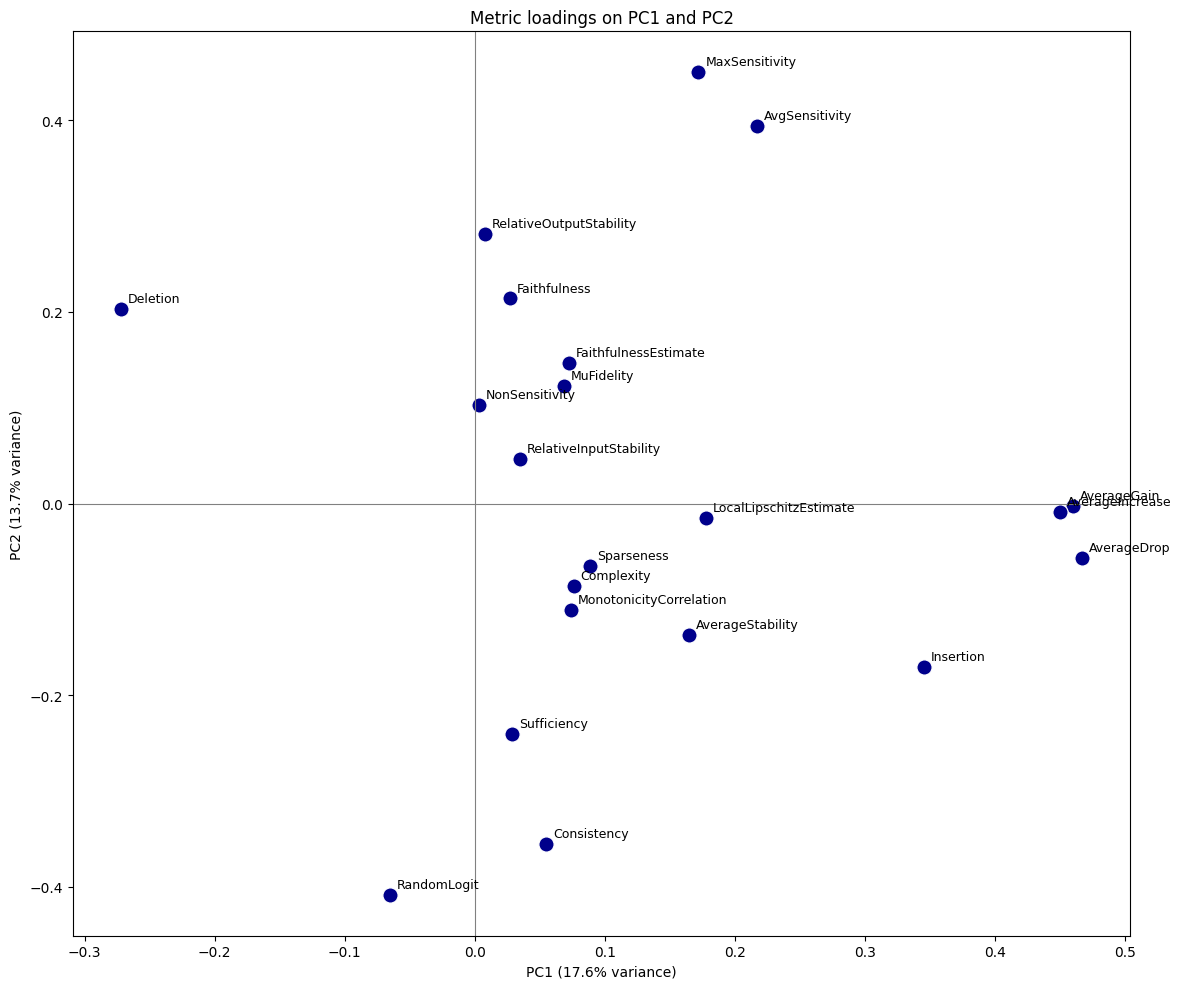

In [120]:
plot_loadings = pca_loadings.reset_index()

plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=plot_loadings,
    x="PC1",
    y="PC2",
    s=120,
    color="darkblue",
)

for row in plot_loadings.itertuples():
    plt.annotate(
        row.metric,
        (row.PC1, row.PC2),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)

plt.title("Metric loadings on PC1 and PC2")
plt.xlabel(
    f"PC1 ({explained_variance.loc[0, 'explained_variance_pct']:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({explained_variance.loc[1, 'explained_variance_pct']:.1f}% variance)"
)

plt.tight_layout()
plt.show()